In [58]:
# loading libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
import numpy as np
from pathlib import Path
import os
from scipy.optimize import curve_fit, minimize_scalar
import matplotlib.dates as mdates
import warnings
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy.stats import levene
warnings.filterwarnings("ignore")


# Loading the dfs


In [59]:
#Loading the energy dataframe
base_path = Path(os.getcwd())

input_path  = base_path / r"..\..\Data\Cleaned\df_energy_cleaned.parquet"

output_path = base_path / r"..\..\Data\Modelled\df_energy_modelled.parquet"

models_path  = Path("../../Code/Models")

df_energy  = pd.read_parquet(input_path)

In [60]:
#Loading the GHI dataframe
input_path  = base_path / r"..\..\Data\Cleaned\df_bologna_cleaned.parquet"

df_weather = pd.read_parquet(input_path)

In [61]:
df_weather

,index,time,latitude,longitude,t2m,SSRD_Wm2,CLEAR_SKY_GHI,GHI,GHI_index
0,0,2005-01-01 01:00:00,45.5,11.25,0.368042,0.0,0.0,0.0,NaN
1,1,2005-01-01 02:00:00,45.5,11.25,0.558685,0.0,0.0,0.0,NaN
2,2,2005-01-01 03:00:00,45.5,11.25,0.467987,0.0,0.0,0.0,NaN
3,3,2005-01-01 04:00:00,45.5,11.25,0.576385,0.0,0.0,0.0,NaN
4,4,2005-01-01 05:00:00,45.5,11.25,0.582214,0.0,0.0,0.0,NaN
...,...,...,...,...,...,...,...,...,...
184074,184074,2025-12-31 19:00:00,45.5,11.25,-0.786285,0.0,0.0,0.0,NaN
184075,184075,2025-12-31 20:00:00,45.5,11.25,-1.193817,0.0,0.0,0.0,NaN
184076,184076,2025-12-31 21:00:00,45.5,11.25,-1.493530,0.0,0.0,0.0,NaN
184077,184077,2025-12-31 22:00:00,45.5,11.25,-2.381805,0.0,0.0,0.0,NaN


# Parameters

In [62]:
ENERGY_DATE_COL    = "date"
WEATHER_DATE_COL   = "date"          # already daily → must have a date column
PRICE_COL          = "price_NORD_EURMWh"
ZERO_FLAG_COL      = "zero_flag"
IMPUTED_FLAG_COL   = "imputed_flag"
TEMP_COL           = "t2m"           # daily mean temperature in df_weather
KT_COL             = "GHI_index"     # daily mean clearness index in df_weather

In [63]:
# ── Crisis regime window (energy crisis 2021-2023) ───────────────────────────
CRISIS_START = "2021-10-01"
CRISIS_END   = "2023-06-30"
 

In [64]:
df_energy["datetime"] = pd.to_datetime(df_energy["datetime"])
df_energy["date"]     = pd.to_datetime(df_energy["date"])
 
df_weather["time"] = pd.to_datetime(df_weather["time"])
df_weather["date"] = df_weather["time"].dt.normalize()

df_weather["t2m_celsius"] = df_weather["t2m"]
 
# quick sanity check
print("Energy  rows:", len(df_energy),
      "| date range:", df_energy["date"].min().date(),
      "→", df_energy["date"].max().date())
print("Weather rows:", len(df_weather),
      "| date range:", df_weather["date"].min().date(),
      "→", df_weather["date"].max().date())

Energy  rows: 186024 | date range: 2005-01-01 → 2026-03-22
Weather rows: 184079 | date range: 2005-01-01 → 2025-12-31


# Agregating daily statistics 

In [65]:
# Agregating energy prices

clean = (df_energy["zero_flag"] == 0) & (df_energy["imputed_flag"] == 0)
 
# daily mean on clean hours only
daily_mean_clean = (
    df_energy[clean]
    .groupby("date")["price_NORD_EURMWh"]
    .mean()
    .rename("daily_mean_clean")
)

In [66]:
# standard aggregations
daily_e = df_energy.groupby("date").agg(
    daily_mean      = ("daily_mean",        "first"),   # pre-computed in df
    daily_max       = ("daily_max",         "first"),
    daily_min       = ("daily_min",         "first"),
    daily_spread    = ("daily_spread",      "first"),
    p95_year        = ("p95_year",          "first"),
    bess_arb_proxy  = ("bess_arb_proxy",    "max"),
    fwd_max_24h     = ("fwd_max_24h",       "max"),
    rolling_std_7d  = ("rolling_std_7d",    "last"),
    rolling_std_30d = ("rolling_std_30d",   "last"),
    rolling_mean_7d = ("rolling_mean_7d",   "last"),
    rolling_mean_30d= ("rolling_mean_30d",  "last"),
    year            = ("year",              "first"),
    month           = ("month",             "first"),
    quarter         = ("quarter",           "first"),
    week            = ("week",              "first"),
    weekday         = ("weekday",           "first"),
    is_weekend      = ("is_weekend",        "first"),
    any_zero        = ("zero_flag",         "max"),
    any_imputed     = ("imputed_flag",      "max"),
    any_price_flag  = ("price_flag",        "max"),
).reset_index()
 
# attach clean mean
daily_e = daily_e.merge(daily_mean_clean, on="date", how="left")
 
# fallback: if clean mean is NaN use the raw daily mean
daily_e["daily_mean_clean"] = daily_e["daily_mean_clean"].fillna(daily_e["daily_mean"])
 
print("\nDaily energy rows:", len(daily_e))
print("Missing clean mean:", daily_e["daily_mean_clean"].isna().sum())


Daily energy rows: 7751
Missing clean mean: 0


In [67]:
daily_w = df_weather.groupby("date").agg(
    t2m_daily        = ("t2m_celsius",   "mean"),
    KT_daily         = ("GHI_index",     "mean"),
    GHI_daily_sum    = ("GHI",           "sum"),
    SSRD_daily_sum   = ("SSRD_Wm2",      "sum"),
    clear_sky_daily  = ("CLEAR_SKY_GHI", "sum"),
).reset_index()
 

daily_w["KT_daily"] = (
    daily_w["GHI_daily_sum"] /
    daily_w["clear_sky_daily"].clip(lower=1.0)
).clip(0.0, 1.0)
 
print("\nDaily weather rows:", len(daily_w))
print("KT_daily range:", daily_w["KT_daily"].min().round(3),
      "→", daily_w["KT_daily"].max().round(3))
 


Daily weather rows: 7670
KT_daily range: 0.091 → 1.0


# Merging dfs

In [68]:
df = daily_e.merge(daily_w, on="date", how="left")
df = df.sort_values("date").reset_index(drop=True)
 
# flag days with no weather data
df["weather_missing"] = df["t2m_daily"].isna().astype(int)

# Drop rows where t2m_daily is missing
df = df.dropna(subset=['t2m_daily'])

 
print("\nMerged daily rows:", len(df))
print("Weather missing days:", df["weather_missing"].sum())


Merged daily rows: 7670
Weather missing days: 0


In [69]:
# Log price + time index 
 
df["log_price"] = np.log(df["daily_mean_clean"].clip(lower=0.01))
df["doy"]       = df["date"].dt.dayofyear
df["t_year"]    = (df["doy"] - 1) / 365.0   # 0–1 repeating annually

In [70]:
#  Crisis regime flag 
# 2022 energy crisis: Oct 2021 – Jun 2023 (captures full spike arc)
 
CRISIS_START = "2021-10-01"
CRISIS_END   = "2023-06-30"
 
df["crisis"] = (
    (df["date"] >= CRISIS_START) &
    (df["date"] <= CRISIS_END)
).astype(int)
 
print(f"\nCrisis regime: {df['crisis'].sum()} days "
      f"({CRISIS_START} → {CRISIS_END})")


Crisis regime: 638 days (2021-10-01 → 2023-06-30)


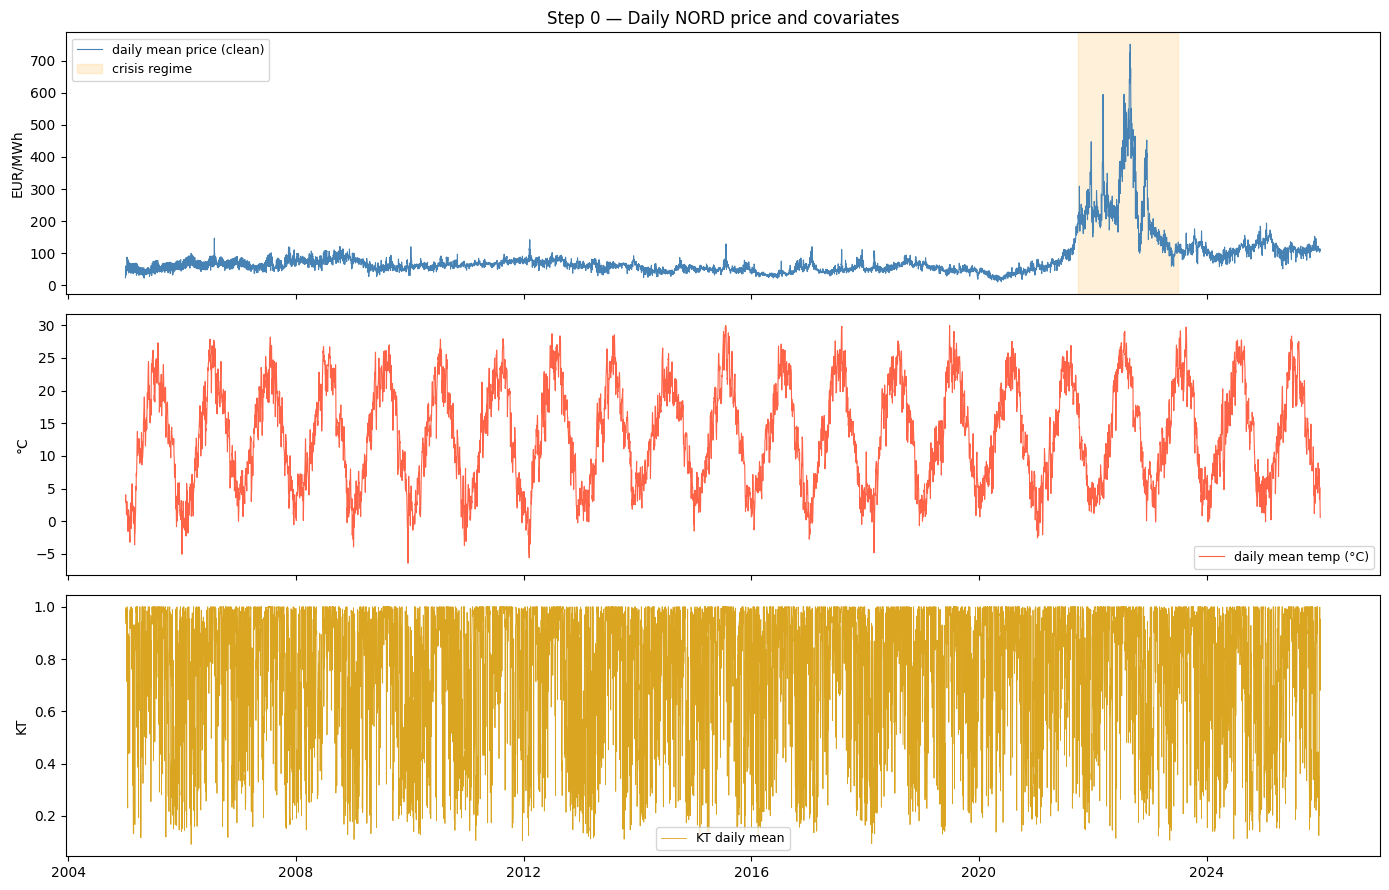

In [71]:
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
 
# panel 1: raw price
axes[0].plot(df["date"], df["daily_mean_clean"], lw=0.8,
             color="steelblue", label="daily mean price (clean)")
axes[0].axvspan(pd.Timestamp(CRISIS_START), pd.Timestamp(CRISIS_END),
                alpha=0.15, color="orange", label="crisis regime")
axes[0].set_ylabel("EUR/MWh")
axes[0].legend(fontsize=9)
axes[0].set_title("Step 0 — Daily NORD price and covariates")
 
# panel 2: temperature
axes[1].plot(df["date"], df["t2m_daily"], lw=0.8,
             color="tomato", label="daily mean temp (°C)")
axes[1].set_ylabel("°C")
axes[1].legend(fontsize=9)
 
# panel 3: KT clearness index
axes[2].plot(df["date"], df["KT_daily"], lw=0.6,
             color="goldenrod", label="KT daily mean")
axes[2].set_ylabel("KT")
axes[2].legend(fontsize=9)
axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
 
plt.tight_layout()
plt.show()
 

In [72]:
print("\n── Summary statistics ───────────────────────────────────────────")
summary = df[["daily_mean_clean", "daily_spread", "t2m_daily",
              "KT_daily", "rolling_std_7d"]].describe().round(2)
print(summary)
 
# split normal vs crisis
print("\n── Price stats: normal vs crisis ───────────────────────────────")
for label, mask in [("Normal", df["crisis"] == 0),
                    ("Crisis", df["crisis"] == 1)]:
    sub = df.loc[mask, "daily_mean_clean"]
    print(f"  {label:7s}  mean={sub.mean():.1f}  std={sub.std():.1f}  "
          f"max={sub.max():.1f}  p95={sub.quantile(0.95):.1f} EUR/MWh")
 


── Summary statistics ───────────────────────────────────────────
       daily_mean_clean  daily_spread  t2m_daily  KT_daily  rolling_std_7d
count           7670.00       7670.00    7670.00   7670.00         7670.00
mean              83.11         61.51      13.30      0.75           20.83
std               66.41         43.44       7.79      0.26           14.49
min               10.70          5.10      -6.40      0.09            3.50
25%               52.03         31.75       6.51      0.55           11.41
50%               65.25         49.94      13.34      0.86           17.02
75%               85.87         78.02      19.96      0.98           26.61
max              751.29        417.77      29.96      1.00          146.07

── Price stats: normal vs crisis ───────────────────────────────
  Normal   mean=67.9  std=25.5  max=219.2  p95=119.4 EUR/MWh
  Crisis   mean=250.3  std=124.0  max=751.3  p95=504.0 EUR/MWh


In [73]:
# 2.1  Solar penetration index from generation mix share
# ─────────────────────────────────────────────────────────────────────────────
# Annual solar share of Italian electricity generation (%).
# Sources: GSE annual statistics, Terna, IEA-PVPS Italy 2024 national survey,
#          Ember Energy, Wikipedia solar power in Italy.
# National share used — NORD zone tracks national closely (~55% of solar
# output, ~50% of national demand concentrated in the north).
 
solar_share_pct = {
    2005: 0.02,
    2006: 0.03,
    2007: 0.05,
    2008: 0.10,
    2009: 0.26,
    2010: 0.63,
    2011: 3.00,
    2012: 5.70,
    2013: 7.40,
    2014: 7.90,
    2015: 7.80,
    2016: 7.90,
    2017: 7.70,
    2018: 7.90,
    2019: 8.60,
    2020: 9.50,
    2021: 9.50,
    2022: 9.50,
    2023: 12.30,
    2024: 11.50,
}
 
REFERENCE_SHARE = solar_share_pct[2024]   # 11.5% — normalisation anchor
 
print("── Solar share and penetration index ────────────────────────────")
print(f"  Reference share (2024): {REFERENCE_SHARE}%")
print(f"  {'Year':>4}  {'Share%':>8}  {'Index':>7}")
for yr in sorted(solar_share_pct):
    print(f"  {yr:>4}  {solar_share_pct[yr]:>8.2f}  "
          f"{solar_share_pct[yr]/REFERENCE_SHARE:>7.4f}")
 

── Solar share and penetration index ────────────────────────────
  Reference share (2024): 11.5%
  Year    Share%    Index
  2005      0.02   0.0017
  2006      0.03   0.0026
  2007      0.05   0.0043
  2008      0.10   0.0087
  2009      0.26   0.0226
  2010      0.63   0.0548
  2011      3.00   0.2609
  2012      5.70   0.4957
  2013      7.40   0.6435
  2014      7.90   0.6870
  2015      7.80   0.6783
  2016      7.90   0.6870
  2017      7.70   0.6696
  2018      7.90   0.6870
  2019      8.60   0.7478
  2020      9.50   0.8261
  2021      9.50   0.8261
  2022      9.50   0.8261
  2023     12.30   1.0696
  2024     11.50   1.0000


In [74]:
# ── interpolate to daily frequency using decimal year ─────────────────────
# Anchored at 1 Jan of each year. Flat after 2024 (no forecast here).
 
lookup_years = np.array(sorted(solar_share_pct) + [2025], dtype=float)
lookup_vals  = np.array(
    [solar_share_pct[yr] / REFERENCE_SHARE for yr in sorted(solar_share_pct)]
    + [solar_share_pct[2024] / REFERENCE_SHARE],
    dtype=float
)
 
# decimal year per row — avoids all datetime dtype/precision issues
df_decimal_year = df["year"].astype(float) + (df["doy"] - 1) / 365.0
 
df["penetration_index"] = np.interp(df_decimal_year, lookup_years, lookup_vals)
 
print(f"\n── penetration_index in df ──────────────────────────────────────")
for yr in [2005, 2010, 2013, 2015, 2020, 2024]:
    mask = df["year"] == yr
    if mask.any():
        print(f"  {yr}: {df.loc[mask, 'penetration_index'].mean():.4f}")
 


── penetration_index in df ──────────────────────────────────────
  2005: 0.0022
  2010: 0.1575
  2013: 0.6652
  2015: 0.6826
  2020: 0.8261
  2024: 1.0000


# Seasonal Decomposition

In [75]:
# Fourier seasonal fit  (identical to original Step 1)
# ─────────────────────────────────────────────────────────────────────────────
 
N_HARMONICS = 4
 
def fourier_seasonal(t, *params):
    out = np.full_like(t, params[0], dtype=float)
    K   = (len(params) - 1) // 2
    for k in range(1, K + 1):
        out += params[2*k-1] * np.cos(2 * np.pi * k * t)
        out += params[2*k]   * np.sin(2 * np.pi * k * t)
    return out
 
n_params = 1 + 2 * N_HARMONICS
p0       = [df["log_price"].mean()] + [0.0] * (n_params - 1)
 
fit_mask = (
    (df["crisis"] == 0) &
    (df["any_zero"] == 0) &
    (df["any_imputed"] == 0) &
    df["log_price"].notna()
).values
 
params, _ = curve_fit(
    fourier_seasonal,
    df.loc[fit_mask, "t_year"].values,
    df.loc[fit_mask, "log_price"].values,
    p0=p0, maxfev=20000
)
 
df["mu_s"] = fourier_seasonal(df["t_year"].values, *params)
 
print(f"Fourier fit: {N_HARMONICS} harmonics")
print(f"  mu_s range: [{df['mu_s'].min():.3f}, {df['mu_s'].max():.3f}]")

Fourier fit: 4 harmonics
  mu_s range: [3.964, 4.251]


In [76]:
# 1.2  Crisis level correction
# ─────────────────────────────────────────────────────────────────────────────
 
crisis_mask          = df["crisis"] == 1
crisis_residual_mean = (
    df.loc[crisis_mask, "log_price"] -
    df.loc[crisis_mask, "mu_s"]
).mean()
 
df["mu_s_eff"] = df["mu_s"] + df["crisis"] * crisis_residual_mean
 
print(f"  Crisis level shift: {crisis_residual_mean:.4f} log-units "
      f"(≈ {np.exp(crisis_residual_mean):.2f}× seasonal level)")


  Crisis level shift: 1.2664 log-units (≈ 3.55× seasonal level)


In [77]:
# 1.5  Build seasonal level and X_raw
# ─────────────────────────────────────────────────────────────────────────────

# Step A: mu_s_full = mu_s_eff only
df["mu_s_full"] = df["mu_s_eff"].copy()

# Step B: first-pass X_raw — needed to estimate weekday × quarter means
df["X_raw"] = df["log_price"] - df["mu_s_full"]

# Step C: estimate seasonal weekday correction (weekday × quarter)
# 28 cells instead of 7 — captures the seasonal variation in the weekend effect
# e.g. Sunday in summer (high solar, low demand) is more suppressed than
# Sunday in winter (low demand, no solar)
wd_q_means = (
    df[(df["crisis"] == 0) &
       (df["any_zero"] == 0) &
       (df["any_imputed"] == 0)]
    .groupby(["quarter", "weekday"])["X_raw"]
    .mean()
)

print("── Weekday × quarter corrections (log-price units) ──────────────")
day_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
print(f"  {'':>5}  " + "  ".join(f"{d:>6}" for d in day_names))
for q in [1, 2, 3, 4]:
    row = "  ".join(
        f"{wd_q_means.get((q, wd), 0):>+6.3f}"
        for wd in range(7)
    )
    print(f"  Q{q}:   {row}")

# Step D: apply correction
df["weekday_correction"] = (
    df.set_index(["quarter", "weekday"])
    .index
    .map(wd_q_means)
    .values
)
df["mu_s_full"] = df["mu_s_full"] + df["weekday_correction"]
df["X_raw"]     = df["log_price"] - df["mu_s_full"]

# Step E: verify — all 28 cells should be ≈ 0
print("\n── Weekday × quarter means after correction (should all be ≈ 0):")
check = (
    df[df["crisis"] == 0]
    .groupby(["quarter", "weekday"])["X_raw"]
    .mean()
    .unstack("weekday")
    .round(5)
)
check.columns = day_names
print(check)

print(f"\nX_raw mean after correction: {df['X_raw'].mean():.5f}")
print(f"X_raw std  after correction: {df['X_raw'].std():.5f}")

── Weekday × quarter corrections (log-price units) ──────────────
            Mon     Tue     Wed     Thu     Fri     Sat     Sun
  Q1:   +0.028  +0.051  +0.052  +0.054  +0.044  -0.059  -0.168
  Q2:   +0.030  +0.052  +0.064  +0.051  +0.035  -0.066  -0.200
  Q3:   +0.034  +0.067  +0.080  +0.067  +0.048  -0.066  -0.151
  Q4:   +0.015  +0.045  +0.058  +0.041  +0.025  -0.079  -0.159

── Weekday × quarter means after correction (should all be ≈ 0):
             Mon  Tue  Wed      Thu  Fri      Sat      Sun
quarter                                                   
1        0.00000  0.0 -0.0  0.00000  0.0 -0.00413  0.00000
2       -0.00516  0.0  0.0  0.00063  0.0  0.00000 -0.00565
3        0.00000 -0.0 -0.0  0.00000  0.0  0.00000 -0.00176
4       -0.00000  0.0 -0.0 -0.00000  0.0 -0.00000  0.00000

X_raw mean after correction: -0.00036
X_raw std  after correction: 0.34974


In [78]:
# 1.6  Stationarity and variance tests on the new X_raw
# ─────────────────────────────────────────────────────────────────────────────
 
x_adf            = df["X_raw"].dropna().values
adf_stat, p_adf, _, _, crit, _ = adfuller(x_adf, autolag="AIC")
 
print(f"\n── ADF test on X_raw ────────────────────────────────────────────")
print(f"  ADF stat : {adf_stat:.4f}")
print(f"  p-value  : {p_adf:.4f}  "
      f"{'✓ stationary' if p_adf < 0.05 else '✗ non-stationary'}")
print(f"  Crit 5%  : {crit['5%']:.3f}")
 
x_normal = df.loc[df["crisis"] == 0, "X_raw"].dropna().values
x_crisis  = df.loc[df["crisis"] == 1, "X_raw"].dropna().values
lev_stat, lev_p = levene(x_normal, x_crisis)
print(f"\n── Levene test (normal vs crisis) ───────────────────────────────")
print(f"  stat={lev_stat:.3f}  p={lev_p:.4f}  "
      f"{'✓ different variance' if lev_p < 0.05 else '— homogeneous'}")


── ADF test on X_raw ────────────────────────────────────────────
  ADF stat : -4.1414
  p-value  : 0.0008  ✓ stationary
  Crit 5%  : -2.862

── Levene test (normal vs crisis) ───────────────────────────────
  stat=79.632  p=0.0000  ✓ different variance


In [79]:
# 1.7  Verify: KT signal is present in X_raw (no correction applied)
# ─────────────────────────────────────────────────────────────────────────────

from scipy.stats import pearsonr

check_mask = (
    (df["crisis"] == 0) &
    df["KT_daily"].notna() &
    df["X_raw"].notna() &
    df["t2m_daily"].notna()
).values

C_check  = df.loc[check_mask, "t2m_daily"].values
KT_check = df.loc[check_mask, "KT_daily"].values
X_check  = df.loc[check_mask, "X_raw"].values

C_ctrl = np.column_stack([C_check, C_check**2, np.ones(check_mask.sum())])

def residualise(y, X):
    b = np.linalg.lstsq(X, y, rcond=None)[0]
    return y - X @ b

res_KT = residualise(KT_check, C_ctrl)
res_X  = residualise(X_check,  C_ctrl)

r_raw, p_raw = pearsonr(KT_check, X_check)
r_partial, p_partial = pearsonr(res_KT, res_X)

print("── Verification: KT signal in X_raw (no solar correction) ──────")
print(f"  Raw corr(KT, X_raw)              = {r_raw:+.4f}  p={p_raw:.4f}")
print(f"  Partial corr(KT, X_raw | temp)   = {r_partial:+.4f}  p={p_partial:.4f}")
print(f"\n  This partial correlation will enter the 3×3 covariance matrix")
print(f"  as ρ(price, KT) ≈ {r_partial:.4f} for joint simulation.")

── Verification: KT signal in X_raw (no solar correction) ──────
  Raw corr(KT, X_raw)              = -0.0215  p=0.0709
  Partial corr(KT, X_raw | temp)   = -0.0372  p=0.0018

  This partial correlation will enter the 3×3 covariance matrix
  as ρ(price, KT) ≈ -0.0372 for joint simulation.


# Composite Activity Rate

In [80]:
# 2.1  Demand function g(C) = p1·C² + p2·C + p3
# ─────────────────────────────────────────────────────────────────────────────
 
C      = df["t2m_daily"].values
y_std  = df["rolling_std_7d"].values
y_norm = y_std / np.nanmean(y_std)
 
fit_mask = (
    (df["crisis"] == 0) &
    df["t2m_daily"].notna() &
    df["rolling_std_7d"].notna()
).values
 
X_ols = np.column_stack([
    C[fit_mask]**2,
    C[fit_mask],
    np.ones(fit_mask.sum())
])
coeffs, _, _, _ = np.linalg.lstsq(X_ols, y_norm[fit_mask], rcond=None)
p1, p2, p3 = coeffs
 
if p1 <= 0:
    print("  WARNING: p1 ≤ 0 → using Borovkova & Schmeck default values")
    p1, p2, p3 = 0.01, -0.17, 1.57
 
C_star     = -p2 / (2 * p1)
g_C        = np.clip(p1 * C**2 + p2 * C + p3, 0, None)
tau_demand = np.log1p(g_C)
 
print("── Demand function g(C) ─────────────────────────────────────────")
print(f"  p1={p1:.5f},  p2={p2:.5f},  p3={p3:.5f}")
print(f"  C* (neutral temperature) = {C_star:.1f} °C")
print(f"  τ_demand: [{tau_demand.min():.3f}, {tau_demand.max():.3f}]  "
      f"mean={tau_demand.mean():.3f}")

── Demand function g(C) ─────────────────────────────────────────
  p1=0.00064,  p2=-0.02154,  p3=1.00817
  C* (neutral temperature) = 16.7 °C
  τ_demand: [0.603, 0.776]  mean=0.628


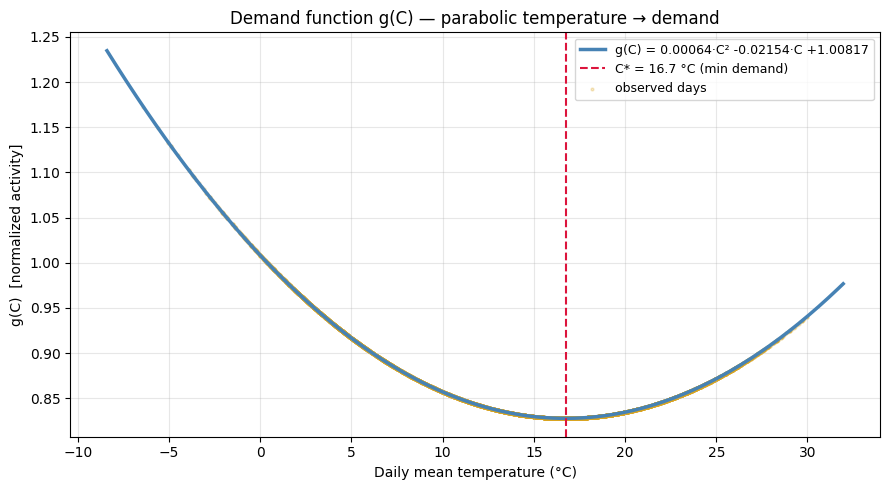

In [81]:
# ── Plot demand function g(C) = p1·C² + p2·C + p3 ───────────────────────────

C_range = np.linspace(df["t2m_daily"].min() - 2, df["t2m_daily"].max() + 2, 300)
g_range = np.clip(p1 * C_range**2 + p2 * C_range + p3, 0, None)

fig, ax = plt.subplots(figsize=(9, 5))

# fitted curve
ax.plot(C_range, g_range, color="steelblue", lw=2.5,
        label=f"g(C) = {p1:.5f}·C² {p2:+.5f}·C {p3:+.5f}")

# neutral temperature
ax.axvline(C_star, color="crimson", ls="--", lw=1.5,
           label=f"C* = {C_star:.1f} °C (min demand)")

# scatter: actual daily observations
ax.scatter(df["t2m_daily"], g_C, s=4, alpha=0.25, color="goldenrod",
           label="observed days")

ax.set_xlabel("Daily mean temperature (°C)")
ax.set_ylabel("g(C)  [normalized activity]")
ax.set_title("Demand function g(C) — parabolic temperature → demand")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


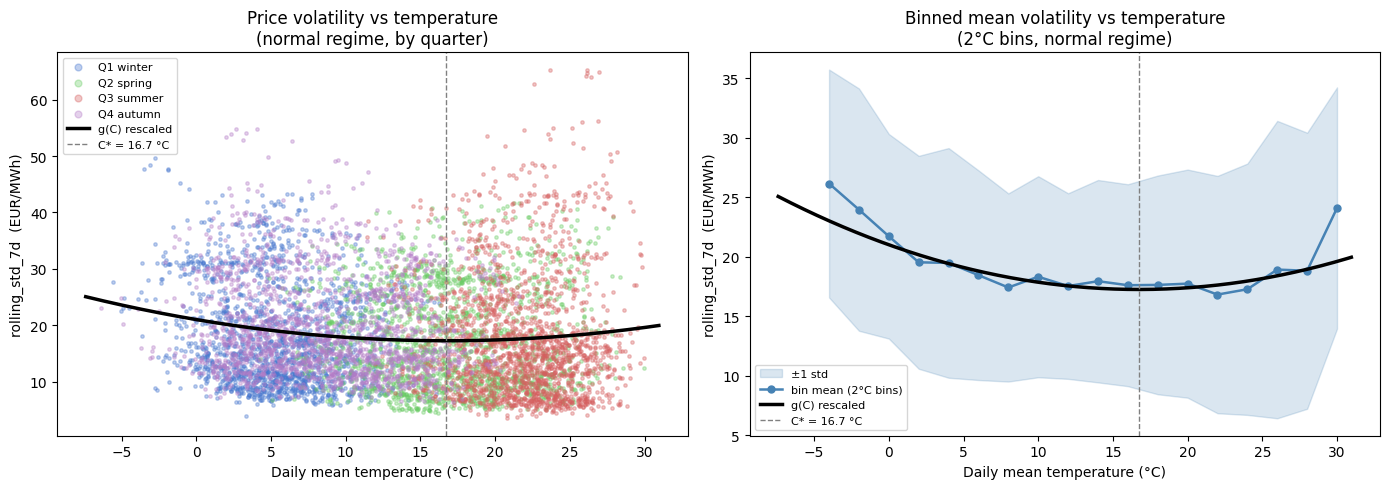

── g(C) fit quality (rescaled to EUR/MWh) ───────────────────────
  R²               = 0.0128
  Residual std     = 9.2843 EUR/MWh
  C* (min demand)  = 16.7 °C
  Scale factor     = 20.8301
  Observations     = 7032


In [82]:
"""
DIAGNOSTIC — Scatter: price volatility vs temperature with g(C) overlay
Requires: df with t2m_daily, rolling_std_7d, crisis columns
          p1, p2, p3, C_star already estimated in block 2.2
"""



# exclude crisis and missing rows for a clean view
plot_mask = (
    (df["crisis"] == 0) &
    df["t2m_daily"].notna() &
    df["rolling_std_7d"].notna()
).values

C_plot    = df.loc[plot_mask, "t2m_daily"].values
vol_plot  = df.loc[plot_mask, "rolling_std_7d"].values

# colour by quarter so seasonal structure is visible
quarter_plot = df.loc[plot_mask, "quarter"].values
colors = {1: "#4878CF", 2: "#6ACC65", 3: "#D65F5F", 4: "#B47CC7"}
labels = {1: "Q1 winter", 2: "Q2 spring", 3: "Q3 summer", 4: "Q4 autumn"}

# ── fitted parabola ──────────────────────────────────────────────────────────

C_range = np.linspace(C_plot.min() - 1, C_plot.max() + 1, 400)
g_range = np.clip(p1 * C_range**2 + p2 * C_range + p3, 0, None)

# scale g(C) to the same units as rolling_std_7d for overlay
# g(C) is dimensionless; rescale so its mean matches the mean of vol_plot
scale = vol_plot.mean() / np.clip(
    p1 * C_plot**2 + p2 * C_plot + p3, 0, None
).mean()
g_scaled = g_range * scale

# ── plot ─────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# left panel: scatter coloured by quarter
ax = axes[0]
for q in [1, 2, 3, 4]:
    m = quarter_plot == q
    ax.scatter(C_plot[m], vol_plot[m],
               s=6, alpha=0.35, color=colors[q], label=labels[q])

ax.plot(C_range, g_scaled, color="black", lw=2.5, label="g(C) rescaled")
ax.axvline(C_star, color="grey", lw=1, ls="--",
           label=f"C* = {C_star:.1f} °C")
ax.set_xlabel("Daily mean temperature (°C)")
ax.set_ylabel("rolling_std_7d  (EUR/MWh)")
ax.set_title("Price volatility vs temperature\n(normal regime, by quarter)")
ax.legend(fontsize=8, markerscale=2)

# right panel: binned means with ±1 std band
# bin temperature into 2°C intervals and compute mean/std of volatility
bin_edges  = np.arange(np.floor(C_plot.min()), np.ceil(C_plot.max()) + 2, 2)
bin_mids   = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_means  = []
bin_stds   = []
bin_counts = []

for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):
    m = (C_plot >= lo) & (C_plot < hi)
    if m.sum() >= 5:
        bin_means.append(vol_plot[m].mean())
        bin_stds.append(vol_plot[m].std())
        bin_counts.append(m.sum())
    else:
        bin_means.append(np.nan)
        bin_stds.append(np.nan)
        bin_counts.append(0)

bin_means  = np.array(bin_means)
bin_stds   = np.array(bin_stds)
bin_counts = np.array(bin_counts)
valid_bins = bin_counts >= 5

ax2 = axes[1]
ax2.fill_between(
    bin_mids[valid_bins],
    bin_means[valid_bins] - bin_stds[valid_bins],
    bin_means[valid_bins] + bin_stds[valid_bins],
    alpha=0.20, color="steelblue", label="±1 std"
)
ax2.plot(bin_mids[valid_bins], bin_means[valid_bins],
         "o-", color="steelblue", lw=1.8, ms=5, label="bin mean (2°C bins)")
ax2.plot(C_range, g_scaled, color="black", lw=2.5, label="g(C) rescaled")
ax2.axvline(C_star, color="grey", lw=1, ls="--",
            label=f"C* = {C_star:.1f} °C")
ax2.set_xlabel("Daily mean temperature (°C)")
ax2.set_ylabel("rolling_std_7d  (EUR/MWh)")
ax2.set_title("Binned mean volatility vs temperature\n(2°C bins, normal regime)")
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

# ── goodness of fit summary ───────────────────────────────────────────────────

g_fitted   = np.clip(p1 * C_plot**2 + p2 * C_plot + p3, 0, None) * scale
residuals  = vol_plot - g_fitted
ss_res     = np.sum(residuals**2)
ss_tot     = np.sum((vol_plot - vol_plot.mean())**2)
r_squared  = 1 - ss_res / ss_tot

print(f"── g(C) fit quality (rescaled to EUR/MWh) ───────────────────────")
print(f"  R²               = {r_squared:.4f}")
print(f"  Residual std     = {residuals.std():.4f} EUR/MWh")
print(f"  C* (min demand)  = {C_star:.1f} °C")
print(f"  Scale factor     = {scale:.4f}")
print(f"  Observations     = {plot_mask.sum()}")

In [83]:
#2.2  Normalisation constant k
# ─────────────────────────────────────────────────────────────────────────────
 
normal_mask = ~df["crisis"].astype(bool).values
k_norm      = 1.0 - np.nanmean(tau_demand[normal_mask])
 
df["tau_demand"] = tau_demand
df["tau"]        = np.clip(tau_demand + k_norm, 1e-6, None)
 
print(f"\n── Normalisation ────────────────────────────────────────────────")
print(f"  k = {k_norm:.4f}")
print(f"  τ(t): min={df['tau'].min():.3f}  "
      f"mean={df['tau'].mean():.3f}  max={df['tau'].max():.3f}")
 
print(f"\n  Mean τ by quarter:")
for q in [1, 2, 3, 4]:
    m = df["quarter"] == q
    print(f"    Q{q}: {df.loc[m, 'tau'].mean():.3f}")
 
print(f"\n  Mean τ: normal={df.loc[df['crisis']==0,'tau'].mean():.3f}  "
      f"crisis={df.loc[df['crisis']==1,'tau'].mean():.3f}")


── Normalisation ────────────────────────────────────────────────
  k = 0.3720
  τ(t): min=0.975  mean=1.000  max=1.148

  Mean τ by quarter:
    Q1: 1.023
    Q2: 0.983
    Q3: 0.988
    Q4: 1.006

  Mean τ: normal=1.000  crisis=1.000


In [84]:
# 2.3  Business time T(t) = cumsum(τ(t) · Δt)
# ─────────────────────────────────────────────────────────────────────────────
 
dt = 1.0 
df["T_business"] = np.nancumsum(df["tau"].values * dt)
 
cal_years = len(df) * dt
bus_years = df["T_business"].iloc[-1]
print(f"\n── Business time ────────────────────────────────────────────────")
print(f"  Calendar elapsed : {cal_years:.2f} days")
print(f"  Business elapsed : {bus_years:.2f} days")
print(f"  Speed ratio      : {bus_years/cal_years:.3f}x")


── Business time ────────────────────────────────────────────────
  Calendar elapsed : 7670.00 days
  Business elapsed : 7669.94 days
  Speed ratio      : 1.000x


In [85]:
# 2.4  Brownian motion correlations
# ─────────────────────────────────────────────────────────────────────────────
 
dX = df["X_raw"].diff().values
dC = df["t2m_daily"].diff().values
 
corr_mask      = np.isfinite(dX) & np.isfinite(dC)
rho_price_temp = np.corrcoef(dX[corr_mask], dC[corr_mask])[0, 1]
 
print(f"\n── Brownian motion correlation ──────────────────────────────────")
print(f"  ρ(B_price, B_temp) = {rho_price_temp:+.4f}  [paper EEX: −0.11]")
 
corr_dict = {"rho_price_temp": rho_price_temp}


── Brownian motion correlation ──────────────────────────────────
  ρ(B_price, B_temp) = -0.0137  [paper EEX: −0.11]


# Jump diffusion

In [86]:
from scipy.stats import expon, lognorm, kstest, probplot

In [87]:
# ─────────────────────────────────────────────────────────────────────────────
# 3.1  Daily log-price changes and local volatility
# ─────────────────────────────────────────────────────────────────────────────

dX = df["X_raw"].diff().values
n  = len(dX)

crisis = df["crisis"].values.astype(bool)

# 30-day rolling std on the full series
sigma_local = (
    pd.Series(dX)
    .rolling(30, min_periods=10)
    .std()
    .values
)

global_std  = np.nanstd(dX)
sigma_local = np.where(
    np.isnan(sigma_local) | (sigma_local <= 0),
    global_std,
    sigma_local
)

# ── Path B: cap sigma_local during crisis at the pre-crisis baseline ─────────
# During the crisis the rolling std inflates with the structural volatility
# elevation, making the denominator too large and suppressing jump detection.
# Fix: for crisis days, use the pre-crisis rolling std as the baseline
# so that moves are still judged relative to a normal-regime volatility scale.

pre_crisis_sigma = np.nanmean(sigma_local[~crisis])

sigma_local_adj          = sigma_local.copy()
sigma_local_adj[crisis]  = np.minimum(
    sigma_local[crisis],
    pre_crisis_sigma
)

print(f"── 3.1  Volatility baseline ─────────────────────────────────────")
print(f"  Pre-crisis σ_local mean : {pre_crisis_sigma:.5f}")
print(f"  Crisis σ_local mean     : {sigma_local[crisis].mean():.5f}  (raw)")
print(f"  Crisis σ_local mean     : {sigma_local_adj[crisis].mean():.5f}  (capped)")

# use the adjusted sigma for all downstream calculations
tau    = df["tau"].values
tau_s  = np.where(tau <= 0, 1e-6, tau)
std_move = np.abs(dX) / (sigma_local_adj * np.sqrt(tau_s))

print(f"\n── Standardised move statistics (adj sigma) ─────────────────────")
print(f"  mean  : {np.nanmean(std_move):.3f}")
print(f"  std   : {np.nanstd(std_move):.3f}")
print(f"  p95   : {np.nanpercentile(std_move, 95):.3f}")
print(f"  p99   : {np.nanpercentile(std_move, 99):.3f}")
print(f"  max   : {np.nanmax(std_move):.3f}")

── 3.1  Volatility baseline ─────────────────────────────────────
  Pre-crisis σ_local mean : 0.11880
  Crisis σ_local mean     : 0.11529  (raw)
  Crisis σ_local mean     : 0.10046  (capped)

── Standardised move statistics (adj sigma) ─────────────────────
  mean  : 0.758
  std   : 0.689
  p95   : 2.142
  p99   : 2.951
  max   : 10.402


In [88]:
# 3.2  Threshold selection
# ─────────────────────────────────────────────────────────────────────────────
# Target: overall jump frequency 5–10% in normal regime (paper Section 3.3.1).
# Crisis threshold is higher to avoid classifying structural level shifts
# as individual jump events.
 
TH_NORMAL = 2.0     # ← tune if jump frequency falls outside 5–10%
TH_CRISIS  = 2.0    # ← higher threshold for crisis window
ECHO_DAYS  = 2      # mean-reversion echo window (paper: "next two days")
 
crisis = df["crisis"].values.astype(bool)
 
# preview frequencies at different thresholds (normal regime only)
print(f"\n── 3.2  Jump frequency by threshold (normal regime) ────────────")
print(f"  {'TH':>5}  {'freq%':>7}  {'n_jumps':>8}")
for th in [1.5, 1.8, 2.0, 2.2, 2.5, 3.0]:
    n_j   = (std_move[~crisis] > th).sum()
    freq  = n_j / (~crisis).sum() * 100
    print(f"  {th:>5.1f}  {freq:>7.2f}%  {n_j:>8}")


── 3.2  Jump frequency by threshold (normal regime) ────────────
     TH    freq%   n_jumps
    1.5    13.85%       974
    1.8     8.45%       594
    2.0     6.16%       433
    2.2     4.49%       316
    2.5     2.62%       184
    3.0     0.88%        62


In [89]:
# 3.3  Jump identification
# ─────────────────────────────────────────────────────────────────────────────
 
jump_mask = np.zeros(n, dtype=bool)
 
for t in range(1, n):
    th = TH_CRISIS if crisis[t] else TH_NORMAL
    if std_move[t] > th and np.isfinite(std_move[t]):
        jump_mask[t] = True
        # flag mean-reversion echo: first opposite-direction move within ECHO_DAYS
        for dt in range(1, ECHO_DAYS + 1):
            if t + dt < n and np.isfinite(dX[t + dt]):
                if np.sign(dX[t + dt]) != np.sign(dX[t]):
                    jump_mask[t + dt] = True
                    break
 
n_normal_days  = (~crisis).sum()
n_crisis_days  =   crisis.sum()
n_normal_jumps = (jump_mask & ~crisis).sum()
n_crisis_jumps = (jump_mask &  crisis).sum()
n_total_jumps  = jump_mask.sum()
 
kappa_normal = n_normal_jumps / n_normal_days
kappa_crisis = n_crisis_jumps / max(n_crisis_days, 1)
kappa_overall= n_total_jumps  / n
 
print(f"\n── 3.3  Jump identification results ────────────────────────────")
print(f"  TH_NORMAL = {TH_NORMAL},  TH_CRISIS = {TH_CRISIS}")
print(f"  Total jump days    : {n_total_jumps}  ({kappa_overall*100:.2f}%)")
print(f"  Normal jump days   : {n_normal_jumps}  ({kappa_normal*100:.2f}%)  "
      f"[target: 5–10%]")
print(f"  Crisis jump days   : {n_crisis_jumps}  ({kappa_crisis*100:.2f}%)")
 
# attach to df
df["jump_mask"] = jump_mask


── 3.3  Jump identification results ────────────────────────────
  TH_NORMAL = 2.0,  TH_CRISIS = 2.0
  Total jump days    : 796  (10.38%)
  Normal jump days   : 724  (10.30%)  [target: 5–10%]
  Crisis jump days   : 72  (11.29%)


In [90]:
# 3.4  Extract jump sizes
# ─────────────────────────────────────────────────────────────────────────────
 
jump_moves = dX[jump_mask]
jumps_pos  = jump_moves[jump_moves  > 0]          # positive jumps
jumps_neg  = np.abs(jump_moves[jump_moves < 0])   # negative jumps (abs value)
 
print(f"\n── 3.4  Jump size summary ──────────────────────────────────────")
print(f"  Positive jumps: n={len(jumps_pos)}  "
      f"mean={jumps_pos.mean():.4f}  max={jumps_pos.max():.4f}")
print(f"  Negative jumps: n={len(jumps_neg)}  "
      f"mean={jumps_neg.mean():.4f}  max={jumps_neg.max():.4f}")
print(f"  Pos/neg ratio : {len(jumps_pos)/max(len(jumps_neg),1):.2f}")


── 3.4  Jump size summary ──────────────────────────────────────
  Positive jumps: n=387  mean=0.2350  max=1.2158
  Negative jumps: n=409  mean=0.2135  max=1.2204
  Pos/neg ratio : 0.95


In [91]:
# 3.5  Fit jump size distributions
# ─────────────────────────────────────────────────────────────────────────────
# Positive jumps → exponential (paper Table 5)
# Negative jumps → lognormal   (paper Table 5)
 
# positive: exponential  f(x) = λ·exp(−λx),  mean = 1/λ
loc_pos, scale_pos = expon.fit(jumps_pos, floc=0)
lambda_pos = 1.0 / scale_pos
ks_pos, p_ks_pos   = kstest(jumps_pos, "expon",
                             args=(loc_pos, scale_pos))
 
# negative: lognormal  f(x) = lognormal(μ_ln, σ_ln)
s_neg, loc_neg, scale_neg = lognorm.fit(jumps_neg, floc=0)
mu_ln  = np.log(scale_neg)
sig_ln = s_neg
ks_neg, p_ks_neg = kstest(jumps_neg, "lognorm",
                           args=(s_neg, loc_neg, scale_neg))
 
print(f"\n── 3.5  Jump size distributions ────────────────────────────────")
print(f"  Positive jumps  → Exponential")
print(f"    λ        = {lambda_pos:.4f}  (mean jump = {scale_pos:.4f})")
print(f"    KS stat  = {ks_pos:.4f},  p = {p_ks_pos:.4f}  "
      f"{'✓ good fit' if p_ks_pos > 0.05 else '✗ poor fit'}")
print(f"\n  Negative jumps  → LogNormal")
print(f"    μ_ln     = {mu_ln:.4f}")
print(f"    σ_ln     = {sig_ln:.4f}")
print(f"    mean     = {np.exp(mu_ln + 0.5*sig_ln**2):.4f}")
print(f"    KS stat  = {ks_neg:.4f},  p = {p_ks_neg:.4f}  "
      f"{'✓ good fit' if p_ks_neg > 0.05 else '✗ poor fit'}")
 


── 3.5  Jump size distributions ────────────────────────────────
  Positive jumps  → Exponential
    λ        = 4.2552  (mean jump = 0.2350)
    KS stat  = 0.1737,  p = 0.0000  ✗ poor fit

  Negative jumps  → LogNormal
    μ_ln     = -1.8992
    σ_ln     = 1.0545
    mean     = 0.2610
    KS stat  = 0.1666,  p = 0.0000  ✗ poor fit


In [92]:
# 3.6  Jump intensity summary
# ─────────────────────────────────────────────────────────────────────────────
 
kappa_pos_normal = (jump_mask & ~crisis & (dX > 0)).sum() / n_normal_days
kappa_neg_normal = (jump_mask & ~crisis & (dX < 0)).sum() / n_normal_days
kappa_pos_crisis = (jump_mask &  crisis & (dX > 0)).sum() / max(n_crisis_days, 1)
kappa_neg_crisis = (jump_mask &  crisis & (dX < 0)).sum() / max(n_crisis_days, 1)
 
print(f"\n── 3.6  Jump intensities (jumps per day) ───────────────────────")
print(f"  Normal regime:")
print(f"    κ_overall = {kappa_normal:.5f}  ({kappa_normal*365:.2f} jumps/year)")
print(f"    κ_pos     = {kappa_pos_normal:.5f}  ({kappa_pos_normal*365:.2f} pos/year)")
print(f"    κ_neg     = {kappa_neg_normal:.5f}  ({kappa_neg_normal*365:.2f} neg/year)")
print(f"  Crisis regime:")
print(f"    κ_overall = {kappa_crisis:.5f}  ({kappa_crisis*365:.2f} jumps/year)")
print(f"    κ_pos     = {kappa_pos_crisis:.5f}  ({kappa_pos_crisis*365:.2f} pos/year)")
print(f"    κ_neg     = {kappa_neg_crisis:.5f}  ({kappa_neg_crisis*365:.2f} neg/year)")
 


── 3.6  Jump intensities (jumps per day) ───────────────────────
  Normal regime:
    κ_overall = 0.10296  (37.58 jumps/year)
    κ_pos     = 0.05006  (18.27 pos/year)
    κ_neg     = 0.05290  (19.31 neg/year)
  Crisis regime:
    κ_overall = 0.11285  (41.19 jumps/year)
    κ_pos     = 0.05486  (20.02 pos/year)
    κ_neg     = 0.05799  (21.17 neg/year)


In [93]:
# 3.7  Diffusion component: X_raw with jump days removed
# ─────────────────────────────────────────────────────────────────────────────
# Jump days are set to NaN and linearly interpolated.
# This is the series used in Step 4 for OU parameter estimation.
 
X_diffusion = df["X_raw"].copy().values.astype(float)
X_diffusion[jump_mask] = np.nan
X_diffusion = pd.Series(X_diffusion).interpolate(
    method="linear", limit_direction="both"
).values
 
df["X_diffusion"] = X_diffusion
 
print(f"\n── 3.7  Diffusion component ────────────────────────────────────")
print(f"  X_raw std       : {df['X_raw'].std():.4f}")
print(f"  X_diffusion std : {np.nanstd(X_diffusion):.4f}  "
      f"(should be lower — jumps removed)")


── 3.7  Diffusion component ────────────────────────────────────
  X_raw std       : 0.3497
  X_diffusion std : 0.3461  (should be lower — jumps removed)


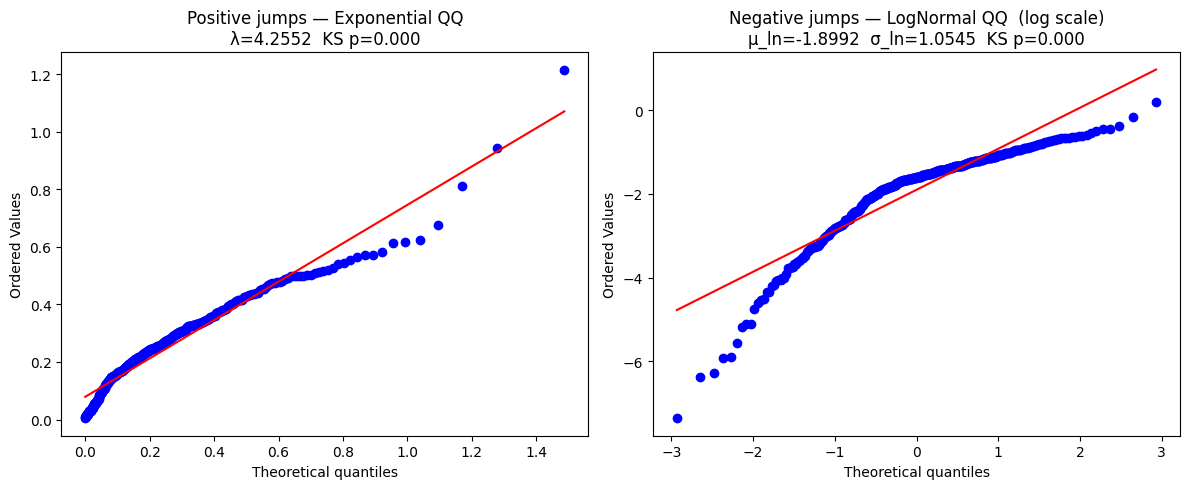

In [94]:
# 3.9  QQ plots for jump size distributions
# ─────────────────────────────────────────────────────────────────────────────
 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
 
probplot(jumps_pos, dist="expon",
         sparams=(loc_pos, scale_pos), plot=axes[0])
axes[0].set_title(f"Positive jumps — Exponential QQ\n"
                  f"λ={lambda_pos:.4f}  KS p={p_ks_pos:.3f}")
 
probplot(np.log(jumps_neg + 1e-8), dist="norm", plot=axes[1])
axes[1].set_title(f"Negative jumps — LogNormal QQ  (log scale)\n"
                  f"μ_ln={mu_ln:.4f}  σ_ln={sig_ln:.4f}  KS p={p_ks_neg:.3f}")
 
plt.tight_layout()
plt.show()


── 3.10  Jump frequency by year (%) ───────────────────────────
  2005: 13.15%  ██████████████████████████
  2006: 12.33%  ████████████████████████
  2007: 11.78%  ███████████████████████
  2008:  9.02%  ██████████████████
  2009: 12.33%  ████████████████████████
  2010: 10.41%  ████████████████████
  2011: 10.68%  █████████████████████
  2012: 13.11%  ██████████████████████████
  2013: 11.78%  ███████████████████████
  2014:  9.59%  ███████████████████
  2015:  9.59%  ███████████████████
  2016:  7.10%  ██████████████
  2017: 10.14%  ████████████████████
  2018: 10.41%  ████████████████████
  2019:  6.58%  █████████████
  2020: 12.02%  ████████████████████████
  2021: 11.23%  ██████████████████████ ← crisis
  2022: 10.96%  █████████████████████ ← crisis
  2023:  9.86%  ███████████████████ ← crisis
  2024:  8.74%  █████████████████
  2025:  7.12%  ██████████████


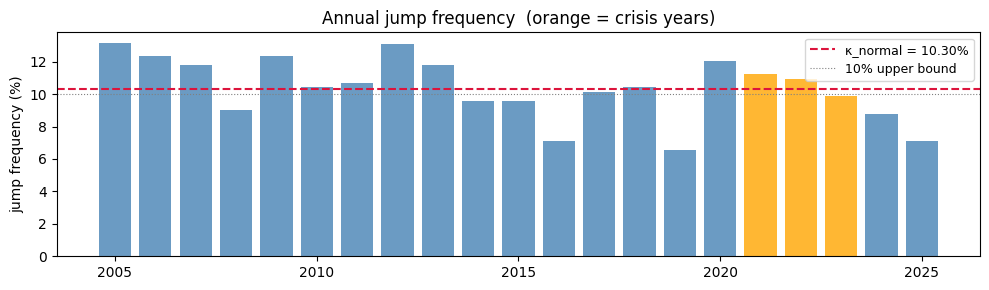

In [95]:
# 3.10  Jump frequency by year — check crisis amplification
# ─────────────────────────────────────────────────────────────────────────────
 
jump_by_year = df.groupby("year")["jump_mask"].mean() * 100
 
print(f"\n── 3.10  Jump frequency by year (%) ───────────────────────────")
for yr, freq in jump_by_year.items():
    bar    = "█" * int(freq / 0.5)
    crisis_flag = " ← crisis" if 2021 <= yr <= 2023 else ""
    print(f"  {yr}: {freq:5.2f}%  {bar}{crisis_flag}")
 
fig, ax = plt.subplots(figsize=(10, 3))
colors_bar = ["orange" if 2021 <= yr <= 2023 else "steelblue"
              for yr in jump_by_year.index]
ax.bar(jump_by_year.index, jump_by_year.values,
       color=colors_bar, alpha=0.8)
ax.axhline(kappa_normal * 100, color="crimson", lw=1.5, ls="--",
           label=f"κ_normal = {kappa_normal*100:.2f}%")
ax.axhline(10, color="grey", lw=0.8, ls=":",
           label="10% upper bound")
ax.set_ylabel("jump frequency (%)")
ax.set_title("Annual jump frequency  (orange = crisis years)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [96]:
# Parameter summary
# ─────────────────────────────────────────────────────────────────────────────
 
jump_params = {
    "TH_normal":      TH_NORMAL,
    "TH_crisis":      TH_CRISIS,
    "kappa_normal":   kappa_normal,
    "kappa_crisis":   kappa_crisis,
    "kappa_pos_normal": kappa_pos_normal,
    "kappa_neg_normal": kappa_neg_normal,
    "kappa_pos_crisis": kappa_pos_crisis,
    "kappa_neg_crisis": kappa_neg_crisis,
    "lambda_pos":     lambda_pos,       # exponential scale for pos jumps
    "mu_ln_neg":      mu_ln,            # lognormal μ for neg jumps
    "sig_ln_neg":     sig_ln,           # lognormal σ for neg jumps
}
 
print("\n── Step 3 complete — parameter summary ─────────────────────────")
print(f"  TH_normal    = {TH_NORMAL}")
print(f"  TH_crisis    = {TH_CRISIS}")
print(f"  κ_normal     = {kappa_normal:.5f}  ({kappa_normal*365:.1f}/year)")
print(f"  κ_crisis     = {kappa_crisis:.5f}  ({kappa_crisis*365:.1f}/year)")
print(f"  λ_pos        = {lambda_pos:.4f}  (exp mean = {scale_pos:.4f})")
print(f"  μ_ln_neg     = {mu_ln:.4f}")
print(f"  σ_ln_neg     = {sig_ln:.4f}")
print(f"\n  Columns added: jump_mask, X_diffusion")
print(f"  Saved: jump_params dict")
 


── Step 3 complete — parameter summary ─────────────────────────
  TH_normal    = 2.0
  TH_crisis    = 2.0
  κ_normal     = 0.10296  (37.6/year)
  κ_crisis     = 0.11285  (41.2/year)
  λ_pos        = 4.2552  (exp mean = 0.2350)
  μ_ln_neg     = -1.8992
  σ_ln_neg     = 1.0545

  Columns added: jump_mask, X_diffusion
  Saved: jump_params dict


# OU Process

In [97]:
# 4.1  Prepare the jump-filtered series in business time
# ─────────────────────────────────────────────────────────────────────────────
# Use only non-jump days for the regression.
# Both normal and crisis days are included — crisis level is already
# corrected in X_raw (Step 1), so X_diffusion is comparable across regimes.
 
clean_mask = (
    ~df["jump_mask"].values &
    df["X_diffusion"].notna() &
    df["T_business"].notna()
)
 
X_clean = df.loc[clean_mask, "X_diffusion"].values
T_clean = df.loc[clean_mask, "T_business"].values
 
print("── 4.1  Estimation sample ───────────────────────────────────────")
print(f"  Total days           : {len(df)}")
print(f"  Jump days removed    : {df['jump_mask'].sum()}")
print(f"  Days used (clean)    : {clean_mask.sum()}")
print(f"  Business time range  : [{T_clean.min():.3f}, {T_clean.max():.3f}] years")
 

── 4.1  Estimation sample ───────────────────────────────────────
  Total days           : 7670
  Jump days removed    : 796
  Days used (clean)    : 6874
  Business time range  : [1.037, 7669.942] years


In [98]:
# 4.2  Build regression variables
# ─────────────────────────────────────────────────────────────────────────────
# ΔX̃ᵢ = X_clean[i] − X_clean[i−1]
# ΔTᵢ = T_clean[i] − T_clean[i−1]  (business time increment, always > 0)
 
dX_clean = np.diff(X_clean)       # length n-1
dT_clean = np.diff(T_clean)       # length n-1
 
# guard: drop any non-positive business time increments
# (can occur if two adjacent clean days are far apart in calendar time
#  but close in business time, or from numerical precision)
valid = (dT_clean > 0) & np.isfinite(dX_clean) & np.isfinite(dT_clean)
dX_v  = dX_clean[valid]
dT_v  = dT_clean[valid]
X_lag = X_clean[:-1][valid]       # X_{i-1} on valid rows
 
sqrt_dT = np.sqrt(dT_v)
 
# regression variables (Eq. 3.7)
y_tilde = dX_v  / sqrt_dT         # dependent variable
x1      = sqrt_dT                  # ← loads on hμ
x2      = X_lag / sqrt_dT          # ← loads on −h
 
print(f"\n── 4.2  Regression sample ───────────────────────────────────────")
print(f"  Observations in regression : {valid.sum()}")
print(f"  Mean ΔT (business days)    : {dT_v.mean()*365:.3f} cal-day equiv.")


── 4.2  Regression sample ───────────────────────────────────────
  Observations in regression : 6873
  Mean ΔT (business days)    : 407.268 cal-day equiv.



── Pre-crisis  2013–2021 ──────────────────────────────────────────────────
  Observations       : 2886
  Period τ mean      : 0.9983
  h  (unrestricted)  : 0.04978  se=0.00605  t=8.22
  μ  (unrestricted)  : -0.18354
  h  (μ=0 restricted): 0.03363
  σ  (μ=0 restricted): 0.09142
  Half-life          : 20.6 calendar days  (at mean τ=0.998)

── Post-crisis 2023–2025 ──────────────────────────────────────────────────
  Observations       : 837
  Period τ mean      : 0.9982
  h  (unrestricted)  : 0.07546  se=0.01413  t=5.34
  μ  (unrestricted)  : 0.50052
  h  (μ=0 restricted): 0.00924
  σ  (μ=0 restricted): 0.07853
  Half-life          : 75.1 calendar days  (at mean τ=0.998)

── Full sample (excl. crisis) ──────────────────────────────────────────────────
  Observations       : 6307
  Period τ mean      : 0.9998
  h  (unrestricted)  : 0.04122  se=0.00370  t=11.14
  μ  (unrestricted)  : 0.00511
  h  (μ=0 restricted): 0.04122
  σ  (μ=0 restricted): 0.09788
  Half-life          : 16.8 calenda

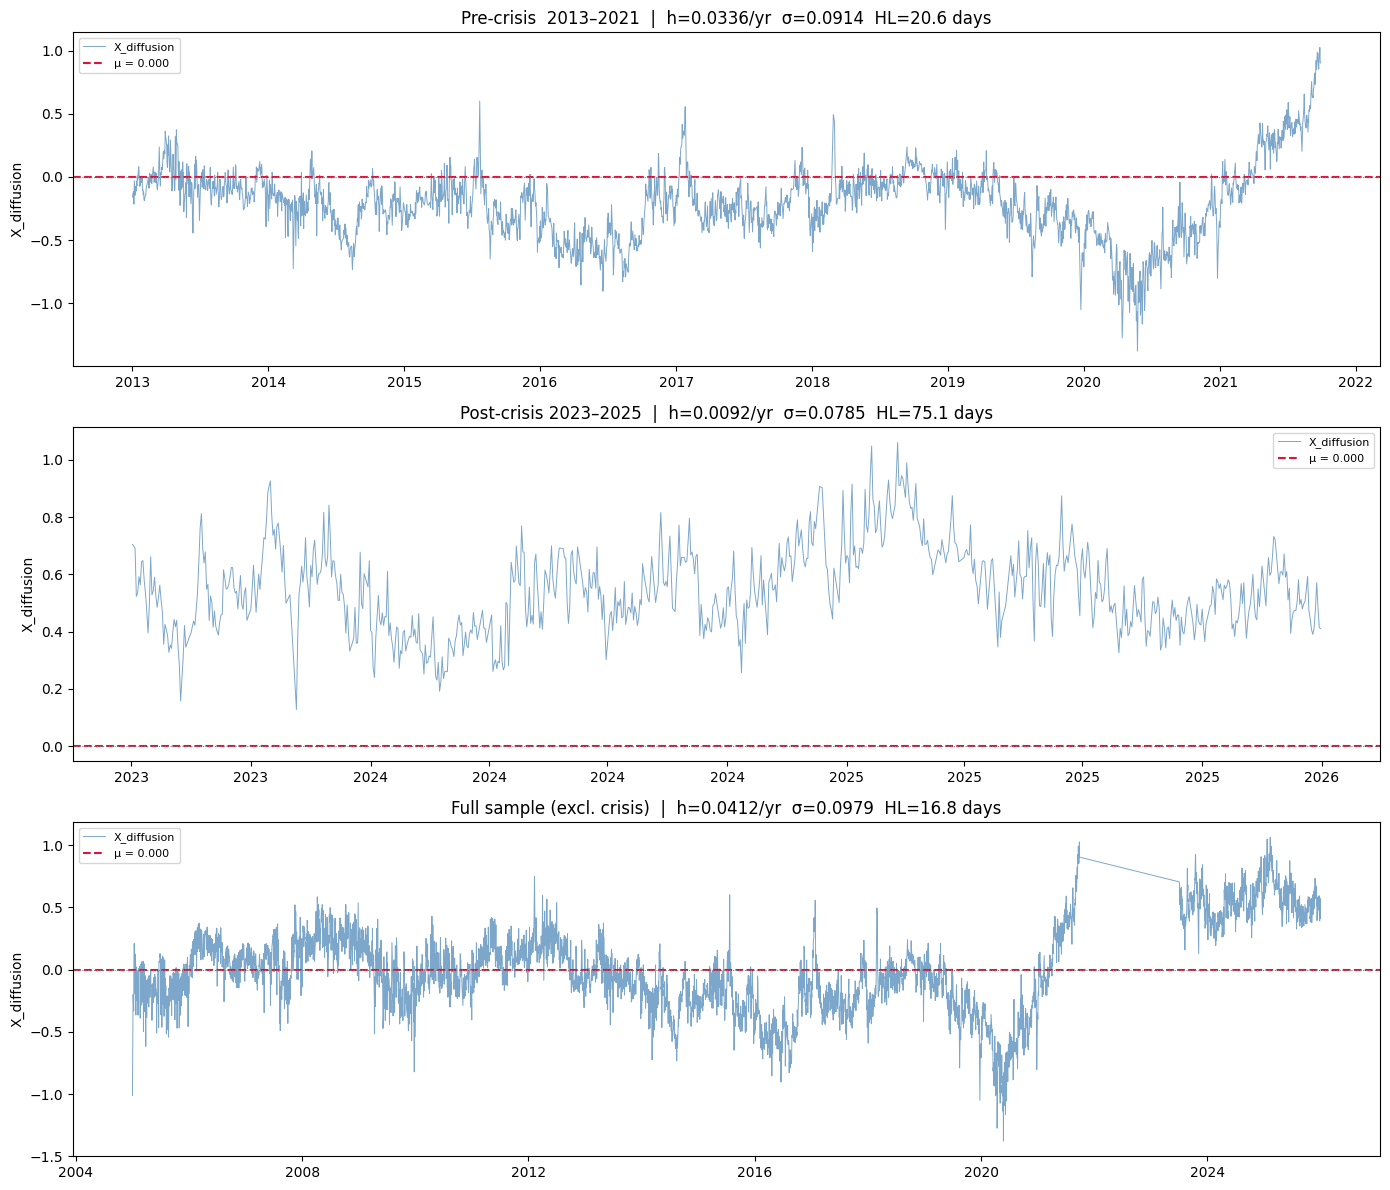


── ou_params saved ──────────────────────────────────────────────
  Baseline (pre-crisis): h=0.03363  σ=0.09142  HL=20.6 days
  Post-crisis          : h=0.00924  σ=0.07853


In [99]:
"""
STEP 4.3 — Extended: OU estimation by regime
==========================================
Estimates h, μ, σ separately for:
  - Pre-crisis  : 2013–2021  (post-boom, stable market)
  - Post-crisis : 2023–2025  (new renewable-dominated regime)
  - Full sample : all non-jump, non-crisis days (for reference)

Prints a comparison table and overlays the mean-reversion paths.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def estimate_ou(df, mask, label):
    """
    Run OLS OU regression on rows selected by mask.
    h is estimated in per-day units (T_business built with dt=1).
    """
    X_s = df.loc[mask, "X_diffusion"].values
    T_s = df.loc[mask, "T_business"].values

    dX_s = np.diff(X_s)
    dT_s = np.diff(T_s)

    valid = (dT_s > 0) & np.isfinite(dX_s) & np.isfinite(dT_s)
    dX_v  = dX_s[valid]
    dT_v  = dT_s[valid]
    X_lag = X_s[:-1][valid]

    sqrt_dT  = np.sqrt(dT_v)
    y_tilde  = dX_v  / sqrt_dT
    x1       = sqrt_dT
    x2       = X_lag / sqrt_dT

    # unrestricted: estimate h and mu
    X_reg  = np.column_stack([x1, x2])
    beta, _, _, _ = np.linalg.lstsq(X_reg, y_tilde, rcond=None)
    beta1, beta2  = beta
    eps    = y_tilde - X_reg @ beta
    h      = float(-beta2)
    mu     = float(-beta1 / beta2) if beta2 != 0 else 0.0
    sigma  = float(np.std(eps, ddof=2))

    # standard errors
    n_obs   = len(y_tilde)
    s2      = np.sum(eps**2) / (n_obs - 2)
    XtX_inv = np.linalg.inv(X_reg.T @ X_reg)
    se_beta = np.sqrt(np.diag(s2 * XtX_inv))
    se_h    = se_beta[1]
    t_h     = h / se_h

    # restricted: fix mu = 0
    x_r     = x2.reshape(-1, 1)
    beta_r, _, _, _ = np.linalg.lstsq(x_r, y_tilde, rcond=None)
    h_r     = float(-beta_r[0])
    eps_r   = y_tilde - x_r @ beta_r
    sigma_r = float(np.std(eps_r, ddof=1))

    # half-life in calendar days — h_r is already in per-day units
    tau_mean = df.loc[mask, "tau"].mean()
    hl_days  = np.log(2) / (h_r * tau_mean) if h_r > 0 else np.inf

    print(f"\n── {label} ──────────────────────────────────────────────────")
    print(f"  Observations       : {valid.sum()}")
    print(f"  Period τ mean      : {tau_mean:.4f}")
    print(f"  h  (unrestricted)  : {h:.5f}  se={se_h:.5f}  t={t_h:.2f}")
    print(f"  μ  (unrestricted)  : {mu:.5f}")
    print(f"  h  (μ=0 restricted): {h_r:.5f}")
    print(f"  σ  (μ=0 restricted): {sigma_r:.5f}")
    print(f"  Half-life          : {hl_days:.1f} calendar days  "
          f"(at mean τ={tau_mean:.3f})")

    return {
        "label":    label,
        "n_obs":    valid.sum(),
        "h":        h_r,
        "mu":       0.0,
        "sigma":    sigma_r,
        "hl_days":  hl_days,
        "tau_mean": tau_mean,
        "X_s":      X_s,
        "T_s":      T_s,
        "dates":    df.loc[mask, "date"].values,
    }

# ── define masks ─────────────────────────────────────────────────────────────

base = (
    ~df["jump_mask"].values &
    df["X_diffusion"].notna() &
    df["T_business"].notna()
)

mask_pre = (
    base &
    (df["crisis"] == 0) &
    (df["year"] >= 2013) &
    (df["year"] <= 2021)
).values

mask_post = (
    base &
    (df["crisis"] == 0) &
    (df["year"] >= 2023)
).values

mask_full = (
    base &
    (df["crisis"] == 0)
).values

# ── run estimations ───────────────────────────────────────────────────────────

res_pre  = estimate_ou(df, pd.Series(mask_pre),  "Pre-crisis  2013–2021")
res_post = estimate_ou(df, pd.Series(mask_post), "Post-crisis 2023–2025")
res_full = estimate_ou(df, pd.Series(mask_full), "Full sample (excl. crisis)")

# ── comparison table ──────────────────────────────────────────────────────────

print("\n── Comparison table ─────────────────────────────────────────────")
print(f"  {'Period':<28}  {'h (μ=0)':>9}  {'σ':>8}  "
      f"{'HL (days)':>10}  {'n':>6}")
print(f"  {'-'*28}  {'-'*9}  {'-'*8}  {'-'*10}  {'-'*6}")
for res in [res_pre, res_post, res_full]:
    print(f"  {res['label']:<28}  {res['h']:>9.5f}  "
          f"{res['sigma']:>8.5f}  {res['hl_days']:>10.1f}  "
          f"{res['n_obs']:>6}")

print(f"\n  Paper (EEX 2009–2012): h≈0.24/day, σ=5.16 EUR/MWh")

# ── visual: X_diffusion by period with mean reversion level ──────────────────

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=False)

for ax, res in zip(axes, [res_pre, res_post, res_full]):
    ax.plot(res["dates"], res["X_s"], lw=0.7,
            color="steelblue", alpha=0.7, label="X_diffusion")
    ax.axhline(res["mu"], color="crimson", lw=1.5, ls="--",
               label=f"μ = {res['mu']:.3f}")
    ax.axhline(0, color="grey", lw=0.8, ls=":")
    ax.set_ylabel("X_diffusion")
    ax.set_title(f"{res['label']}  |  "
                 f"h={res['h']:.4f}/yr  "
                 f"σ={res['sigma']:.4f}  "
                 f"HL={res['hl_days']:.1f} days")
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()
plt.show()

# ── save parameters for simulation ───────────────────────────────────────────
# Use pre-crisis as the baseline for simulation — most stable period.
# Post-crisis can be used for stress-testing or scenario analysis.

ou_params = {
    "h":          res_pre["h"],
    "mu":         0.0,
    "sigma":      res_pre["sigma"],
    "hl_days":    res_pre["hl_days"],
    "h_post":     res_post["h"],
    "sigma_post": res_post["sigma"],
    "h_full":     res_full["h"],
    "sigma_full": res_full["sigma"],
}

print(f"\n── ou_params saved ──────────────────────────────────────────────")
print(f"  Baseline (pre-crisis): h={ou_params['h']:.5f}  "
      f"σ={ou_params['sigma']:.5f}  HL={ou_params['hl_days']:.1f} days")
print(f"  Post-crisis          : h={ou_params['h_post']:.5f}  "
      f"σ={ou_params['sigma_post']:.5f}")

── 4.5.1  Residual summary statistics ───────────────────────────
  Period                            mean       std     skew     kurt       n
  ----------------------------  --------  --------  -------  -------  ------
  Pre-crisis  2013–2021          -0.0064    0.0914   -0.007    1.414    2886
  Post-crisis 2023–2025           0.0051    0.0785    0.010    0.373     837
  Full sample (excl. crisis)      0.0001    0.0979    0.029    1.507    6307

── 4.5.2  Statistical tests ─────────────────────────────────────

  [Pre-crisis  2013–2021]
  Ljung-Box (H0: no autocorrelation):
    lag= 1  p=0.0000  ✗
    lag= 5  p=0.0000  ✗
    lag=10  p=0.0000  ✗
  ARCH-LM (lags=5): p=0.0000  ✗ ARCH present
  Jarque-Bera:      p=0.0000  non-normal (expected)

  [Post-crisis 2023–2025]
  Ljung-Box (H0: no autocorrelation):
    lag= 1  p=0.0000  ✗
    lag= 5  p=0.0000  ✗
    lag=10  p=0.0000  ✗
  ARCH-LM (lags=5): p=0.0005  ✗ ARCH present
  Jarque-Bera:      p=0.0873  approx normal

  [Full sample (excl.

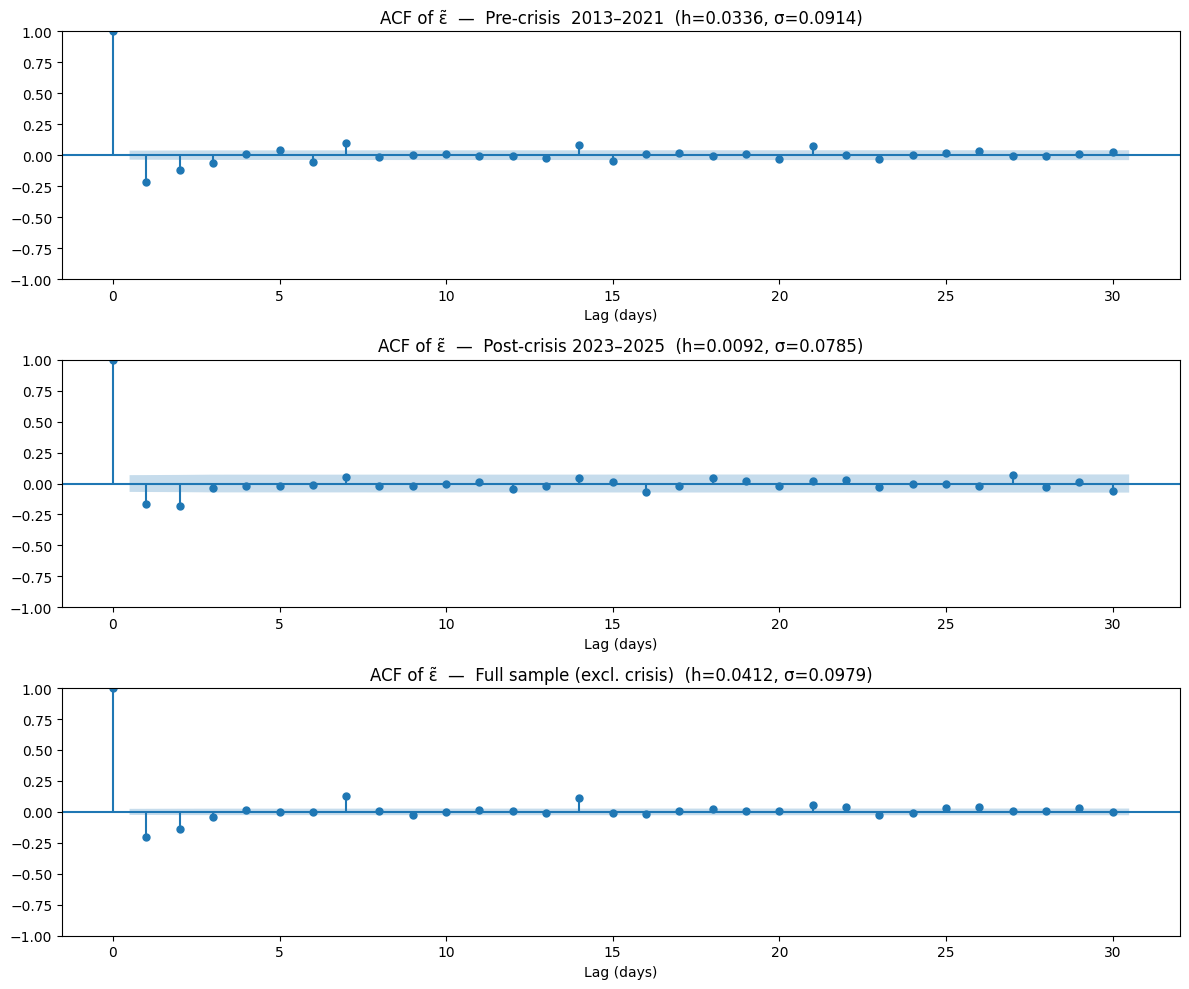

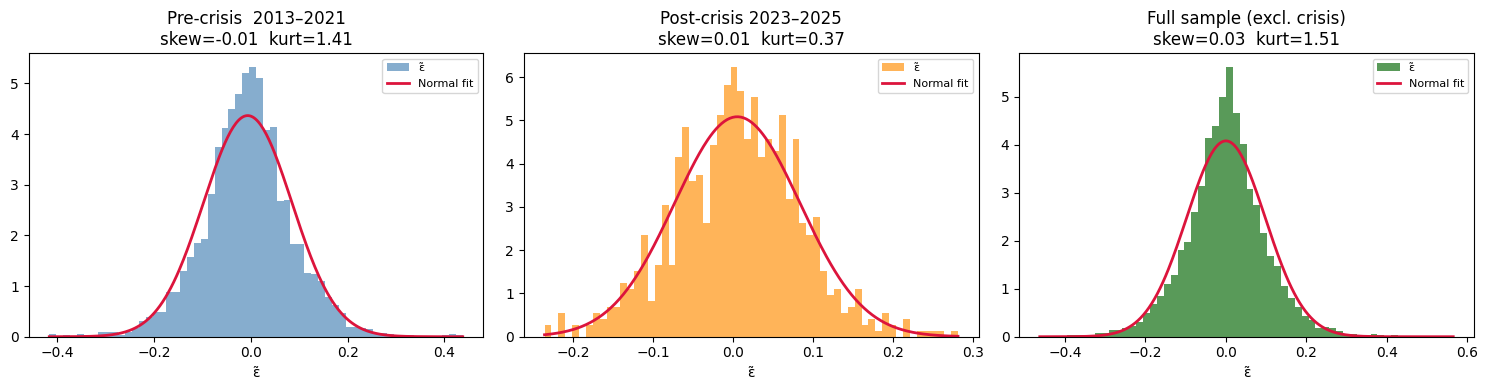

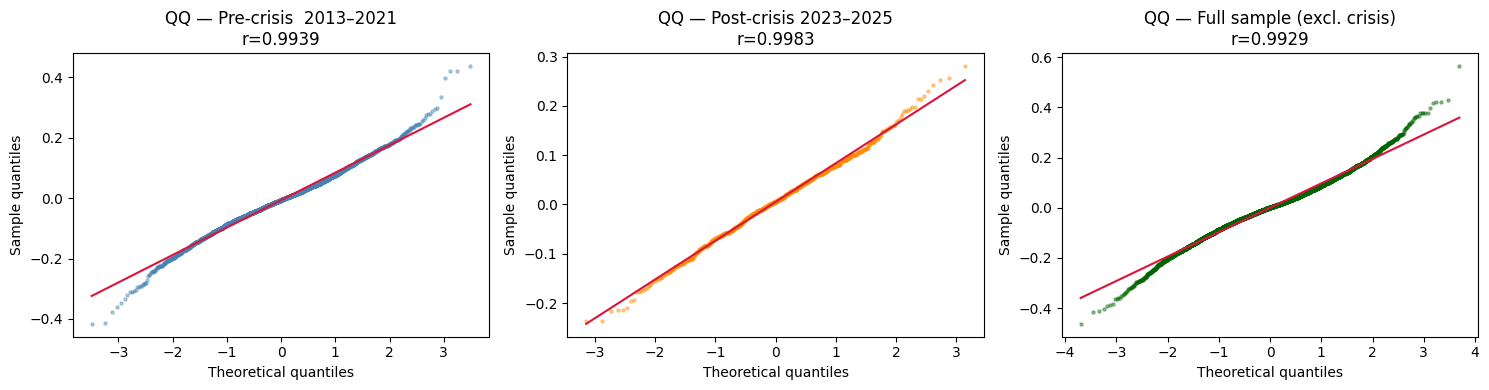

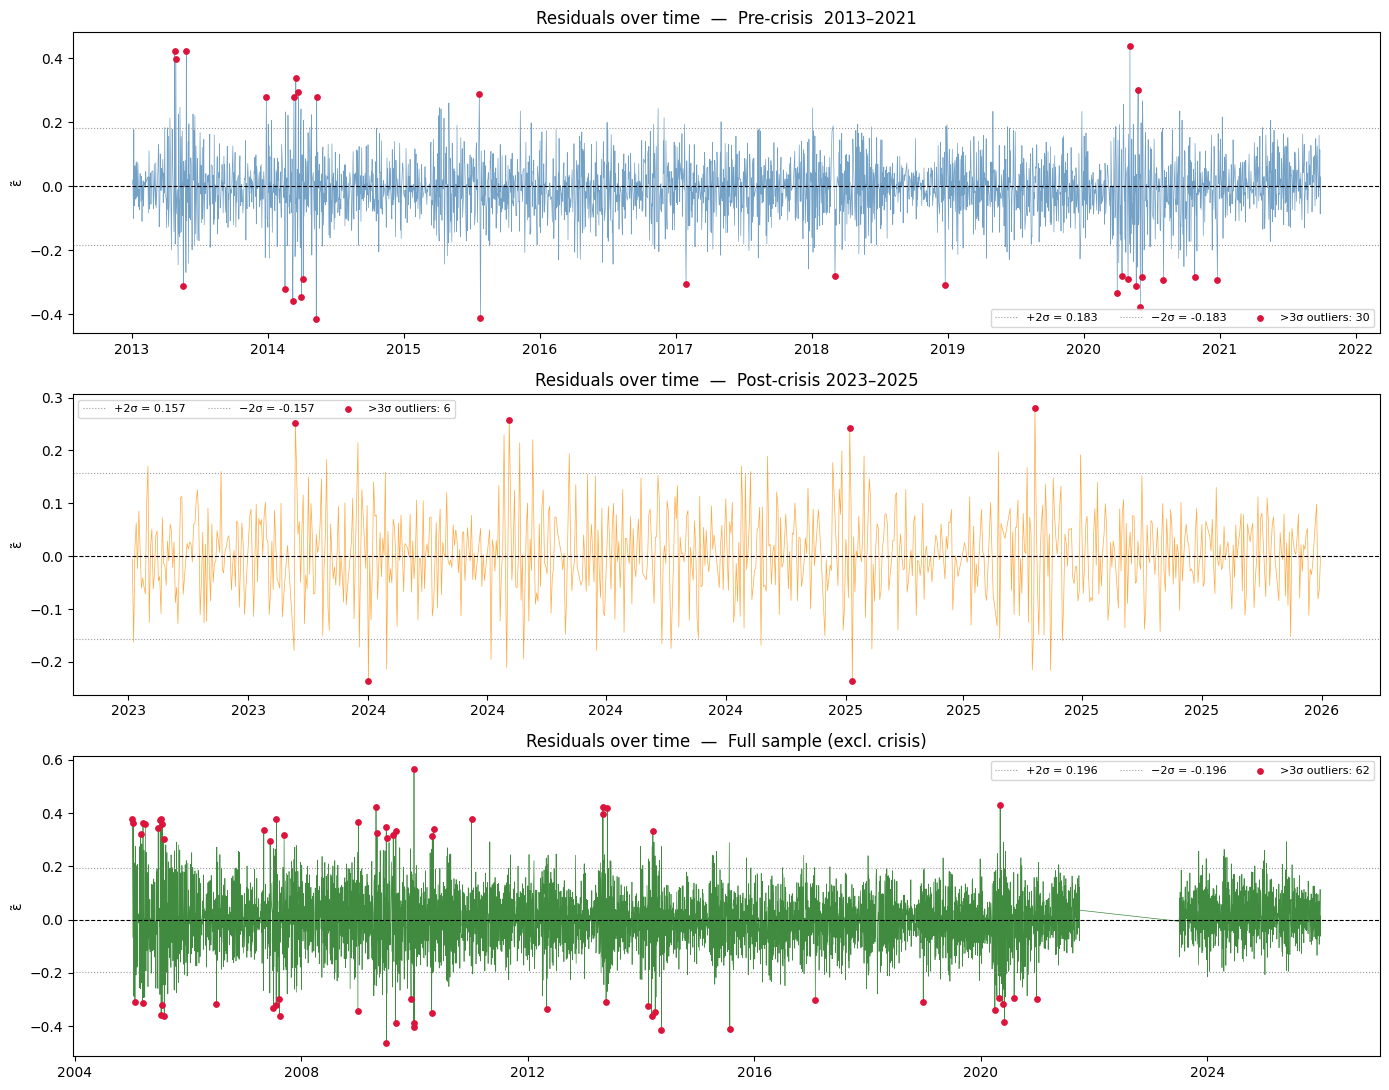

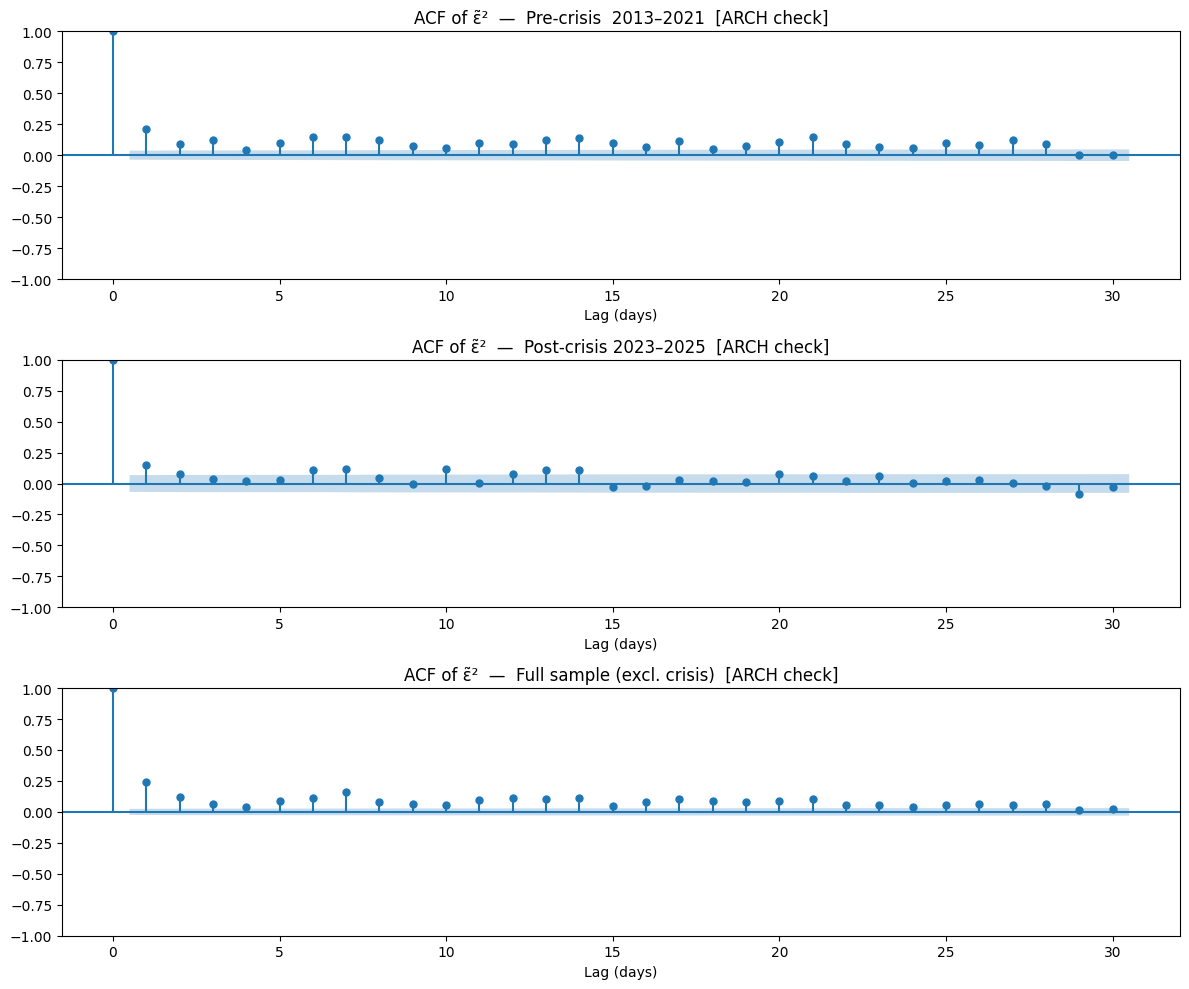


── Interpretation guide ─────────────────────────────────────────
  ACF of ε̃:  bars inside bands → no autocorrelation → OU fit ok
  ACF of ε̃²: bars inside bands → no ARCH → τ(t) explains variance
  Histogram:  heavy tails expected (jump residuals not fully filtered)
  QQ plot:    deviations in tails expected; body should track line
  Time plot:  no persistent runs → no remaining trend/seasonality
  >3σ points: should be rare (<1%) and distributed across all years


In [100]:
"""
STEP 4.5 — Residual Analysis
==============================
Comprehensive residual diagnostics for all three estimation windows:
  - Pre-crisis  2013–2021  (baseline for simulation)
  - Post-crisis 2023–2025
  - Full sample (excl. crisis)

Tests:
  1. Summary statistics
  2. Ljung-Box autocorrelation
  3. ARCH-LM conditional heteroscedasticity
  4. Jarque-Bera normality
  5. Plots: ACF, histogram, residuals over time, QQ

Requires: res_pre, res_post, res_full from the extended block 4.3
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch

# ─────────────────────────────────────────────────────────────────────────────
# reconstruct residuals from a result dict
# ─────────────────────────────────────────────────────────────────────────────

def get_residuals(res):
    """Reconstruct ε̃ from a result dict produced by estimate_ou."""
    X_s   = res["X_s"]
    T_s   = res["T_s"]
    dX_s  = np.diff(X_s)
    dT_s  = np.diff(T_s)
    valid = (dT_s > 0) & np.isfinite(dX_s) & np.isfinite(dT_s)
    sqrt_dT = np.sqrt(dT_s[valid])
    x2_r    = X_s[:-1][valid] / sqrt_dT
    y_r     = dX_s[valid]     / sqrt_dT
    eps     = y_r - x2_r * (-res["h"])    # restricted regression residuals
    dates   = res["dates"][1:][valid]
    return eps, dates

# ─────────────────────────────────────────────────────────────────────────────
# 4.5.1  Summary statistics — all three windows
# ─────────────────────────────────────────────────────────────────────────────

windows = [
    ("Pre-crisis  2013–2021", res_pre),
    ("Post-crisis 2023–2025", res_post),
    ("Full sample (excl. crisis)", res_full),
]

print("── 4.5.1  Residual summary statistics ───────────────────────────")
print(f"  {'Period':<28}  {'mean':>8}  {'std':>8}  "
      f"{'skew':>7}  {'kurt':>7}  {'n':>6}")
print(f"  {'-'*28}  {'-'*8}  {'-'*8}  {'-'*7}  {'-'*7}  {'-'*6}")

all_eps   = {}
all_dates = {}

for label, res in windows:
    eps, dates = get_residuals(res)
    all_eps[label]   = eps
    all_dates[label] = dates
    print(f"  {label:<28}  {eps.mean():>8.4f}  {eps.std():>8.4f}  "
          f"{stats.skew(eps):>7.3f}  {stats.kurtosis(eps):>7.3f}  "
          f"{len(eps):>6}")

# ─────────────────────────────────────────────────────────────────────────────
# 4.5.2  Statistical tests
# ─────────────────────────────────────────────────────────────────────────────

print("\n── 4.5.2  Statistical tests ─────────────────────────────────────")

for label, res in windows:
    eps = all_eps[label]
    print(f"\n  [{label}]")

    # Ljung-Box
    lb  = acorr_ljungbox(eps, lags=[1, 5, 10], return_df=True)
    print(f"  Ljung-Box (H0: no autocorrelation):")
    for lag, row in lb.iterrows():
        sig = "✓" if row["lb_pvalue"] > 0.05 else "✗"
        print(f"    lag={lag:2d}  p={row['lb_pvalue']:.4f}  {sig}")

    # ARCH-LM
    arch_stat, arch_p, _, _ = het_arch(eps, nlags=5)
    arch_sig = "✓ no ARCH" if arch_p > 0.05 else "✗ ARCH present"
    print(f"  ARCH-LM (lags=5): p={arch_p:.4f}  {arch_sig}")

    # Jarque-Bera
    jb_stat, jb_p = stats.jarque_bera(eps)
    jb_sig = "approx normal" if jb_p > 0.05 else "non-normal (expected)"
    print(f"  Jarque-Bera:      p={jb_p:.4f}  {jb_sig}")

# ─────────────────────────────────────────────────────────────────────────────
# 4.5.3  ACF plots — one row per window
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(3, 1, figsize=(12, 10))

for ax, (label, res) in zip(axes, windows):
    eps = all_eps[label]
    plot_acf(eps, lags=30, ax=ax, alpha=0.05)
    ax.set_title(f"ACF of ε̃  —  {label}  "
                 f"(h={res['h']:.4f}, σ={res['sigma']:.4f})")
    ax.set_xlabel("Lag (days)")

plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# 4.5.4  Histogram vs Normal — three panels
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

colors = ["steelblue", "darkorange", "darkgreen"]

for ax, (label, res), col in zip(axes, windows, colors):
    eps = all_eps[label]
    ax.hist(eps, bins=60, density=True,
            color=col, alpha=0.65, label="ε̃")
    x_grid = np.linspace(eps.min(), eps.max(), 300)
    ax.plot(x_grid,
            stats.norm.pdf(x_grid, eps.mean(), eps.std()),
            color="crimson", lw=2, label="Normal fit")
    ax.set_title(f"{label}\nskew={stats.skew(eps):.2f}  "
                 f"kurt={stats.kurtosis(eps):.2f}")
    ax.set_xlabel("ε̃")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# 4.5.5  QQ plots — three panels
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (label, res), col in zip(axes, windows, colors):
    eps = all_eps[label]
    (osm, osr), (slope, intercept, r) = stats.probplot(eps, dist="norm")
    ax.scatter(osm, osr, s=5, alpha=0.4, color=col)
    ax.plot(osm, slope * np.array(osm) + intercept,
            color="crimson", lw=1.5)
    ax.set_title(f"QQ — {label}\nr={r:.4f}")
    ax.set_xlabel("Theoretical quantiles")
    ax.set_ylabel("Sample quantiles")

plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# 4.5.6  Residuals over time — spot remaining structure
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=False)

for ax, (label, res), col in zip(axes, windows, colors):
    eps   = all_eps[label]
    dates = all_dates[label]
    two_sigma = 2 * eps.std()

    ax.plot(dates, eps, lw=0.5, color=col, alpha=0.75)
    ax.axhline(0,           color="black", lw=0.8, ls="--")
    ax.axhline( two_sigma,  color="grey",  lw=0.8, ls=":", alpha=0.8,
                label=f"+2σ = {two_sigma:.3f}")
    ax.axhline(-two_sigma,  color="grey",  lw=0.8, ls=":", alpha=0.8,
                label=f"−2σ = {-two_sigma:.3f}")

    # flag outliers > 3σ
    out_mask = np.abs(eps) > 3 * eps.std()
    ax.scatter(dates[out_mask], eps[out_mask],
               color="crimson", s=15, zorder=5,
               label=f">3σ outliers: {out_mask.sum()}")

    ax.set_ylabel("ε̃")
    ax.legend(fontsize=8, ncol=3)
    ax.set_title(f"Residuals over time  —  {label}")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# 4.5.7  Squared residuals ACF — check for ARCH structure visually
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(3, 1, figsize=(12, 10))

for ax, (label, res) in zip(axes, windows):
    eps = all_eps[label]
    plot_acf(eps**2, lags=30, ax=ax, alpha=0.05,
             title=f"ACF of ε̃²  —  {label}  [ARCH check]")
    ax.set_xlabel("Lag (days)")

plt.tight_layout()
plt.show()

print("\n── Interpretation guide ─────────────────────────────────────────")
print("  ACF of ε̃:  bars inside bands → no autocorrelation → OU fit ok")
print("  ACF of ε̃²: bars inside bands → no ARCH → τ(t) explains variance")
print("  Histogram:  heavy tails expected (jump residuals not fully filtered)")
print("  QQ plot:    deviations in tails expected; body should track line")
print("  Time plot:  no persistent runs → no remaining trend/seasonality")
print("  >3σ points: should be rare (<1%) and distributed across all years")

In [101]:
# check whether lag-7 spike remains and whether it varies by season
print("Weekday × quarter mean X_raw (non-crisis):")
print(
    df[df["crisis"]==0]
    .groupby(["quarter","weekday"])["X_raw"]
    .mean()
    .unstack("weekday")
    .round(4)
)

Weekday × quarter mean X_raw (non-crisis):
weekday       0    1    2       3    4       5       6
quarter                                               
1        0.0000  0.0 -0.0  0.0000  0.0 -0.0041  0.0000
2       -0.0052  0.0  0.0  0.0006  0.0  0.0000 -0.0057
3        0.0000 -0.0 -0.0  0.0000  0.0  0.0000 -0.0018
4       -0.0000  0.0 -0.0 -0.0000  0.0 -0.0000  0.0000


In [102]:
# ── Final calibrated parameters — all steps ──────────────────────────────────

model_params = {
    # Step 1 — Seasonal decomposition
    "N_harmonics":                  N_HARMONICS,
    "fourier_params":               params.tolist(),
    "crisis_start":                 CRISIS_START,
    "crisis_end":                   CRISIS_END,
    "crisis_level_shift":           crisis_residual_mean,
    "weekday_corrections_seasonal": wd_q_means.to_dict(),  # 28-cell quarter×weekday

    # Step 2 — Activity rate
    "p1": p1, "p2": p2, "p3": p3,
    "C_star":                       C_star,
    "k_norm":                       k_norm,
    "tau_min":                      float(df["tau"].min()),
    "tau_max":                      float(df["tau"].max()),
    "rho_price_temp":               rho_price_temp,

    # Step 3 — Jumps
    **jump_params,

    # Step 4 — OU by regime
    "ou_pre_crisis":  {"h": res_pre["h"],  "sigma": res_pre["sigma"],
                       "hl_days": res_pre["hl_days"], "mu": 0.0},
    "ou_post_crisis": {"h": res_post["h"], "sigma": res_post["sigma"],
                       "hl_days": res_post["hl_days"], "mu": 0.0},
    "ou_full":        {"h": res_full["h"], "sigma": res_full["sigma"],
                       "hl_days": res_full["hl_days"], "mu": 0.0},
}

print("── Complete model parameter set ─────────────────────────────────")
for k, v in model_params.items():
    if isinstance(v, dict):
        print(f"  {k:<35} = {{...}}  ({len(v)} entries)")
    elif isinstance(v, list):
        print(f"  {k:<35} = [...]  ({len(v)} values)")
    else:
        print(f"  {k:<35} = {v}")

── Complete model parameter set ─────────────────────────────────
  N_harmonics                         = 4
  fourier_params                      = [...]  (9 values)
  crisis_start                        = 2021-10-01
  crisis_end                          = 2023-06-30
  crisis_level_shift                  = 1.2664248995888137
  weekday_corrections_seasonal        = {...}  (28 entries)
  p1                                  = 0.0006432697064782142
  p2                                  = -0.02154303345845547
  p3                                  = 1.0081726175652195
  C_star                              = 16.74494635881402
  k_norm                              = 0.37201070847954265
  tau_min                             = 0.9751260409941126
  tau_max                             = 1.1479046443374297
  rho_price_temp                      = -0.013746553429401103
  TH_normal                           = 2.0
  TH_crisis                           = 2.0
  kappa_normal                        = 0.102

# Saving the outputs

In [103]:
# ── compute OU residuals ε̃_price before saving ────────────────────────────────
# ε̃(t) = [ΔX_diffusion / √dT] − [−h · X_diffusion(t-1) / √dT]
# uses h from the pre-crisis estimation (baseline for simulation)

X_s = df["X_diffusion"].values
T_s = df["T_business"].values

dX_s    = np.diff(X_s)
dT_s    = np.diff(T_s)
valid   = (dT_s > 0) & np.isfinite(dX_s) & np.isfinite(dT_s)
sqrt_dT = np.sqrt(np.where(valid, dT_s, np.nan))

y_r   = np.where(valid, dX_s / sqrt_dT,           np.nan)
x2_r  = np.where(valid, X_s[:-1] / sqrt_dT,       np.nan)
eps   = np.where(valid, y_r - x2_r * (-res_pre["h"]), np.nan)

# align back to df — eps has one fewer row due to diff
# prepend NaN for the first row
eps_price = np.concatenate([[np.nan], eps])

# also set to NaN on jump days — jumps contaminate the OU innovation
jump_mask = df["jump_mask"].values.astype(bool)
eps_price[jump_mask] = np.nan

df["eps_price"] = eps_price

print(f"  eps_price: {np.isfinite(eps_price).sum()} valid rows  "
      f"mean={np.nanmean(eps_price):.5f}  "
      f"std={np.nanstd(eps_price):.5f}")

# ── save ──────────────────────────────────────────────────────────────────────
cols_to_save = [
    "date", "year", "month", "quarter", "weekday", "doy", "t_year",
    "daily_mean_clean", "log_price", "crisis",
    "mu_s", "mu_s_eff", "weekday_correction",
    "mu_s_full", "X_raw", "KT_daily",
    "penetration_index", "t2m_daily",
    "tau_demand", "tau", "T_business",
    "jump_mask", "X_diffusion",
    "eps_price",              # ← OU innovations for copula
    "rolling_std_7d", "daily_spread", "bess_arb_proxy",
]
df[cols_to_save].to_parquet(output_path, index=False)
print(f"[SAVED] {output_path}  shape={df[cols_to_save].shape}")

  eps_price: 6873 valid rows  mean=0.00011  std=0.09373
[SAVED] c:\Users\LucasMonero\Documents\data projects\Master Thesis\Project\Code\Modelling\..\..\Data\Modelled\df_energy_modelled.parquet  shape=(7670, 27)


In [104]:
# Saving the model parameters

"""
ENERGY PRICE MODEL — Save parameters and models
=================================================
Saves all calibrated model parameters to:
  Code/Models/Energy price/

Saved files:
  price_model_params.pkl   — complete parameter dictionary
  price_ou_params.pkl      — OU-specific parameters for simulation
"""

import pickle
import numpy as np
from pathlib import Path

models_path = Path("../../Code/Models/Energy price")
models_path.mkdir(parents=True, exist_ok=True)

# ─────────────────────────────────────────────────────────────────────────────
# COMPLETE PARAMETER DICTIONARY
# ─────────────────────────────────────────────────────────────────────────────

price_model_params = {

    # ── Step 1: Seasonal decomposition ───────────────────────────────────────
    "N_harmonics":                  N_HARMONICS,
    "fourier_params":               params.tolist(),
    "crisis_start":                 CRISIS_START,
    "crisis_end":                   CRISIS_END,
    "crisis_level_shift":           crisis_residual_mean,
    "weekday_corrections_seasonal": wd_q_means.to_dict(),

    # ── Step 2: Activity rate τ(t) ────────────────────────────────────────────
    "p1":                           p1,
    "p2":                           p2,
    "p3":                           p3,
    "C_star":                       C_star,
    "k_norm":                       k_norm,
    "tau_min":                      float(df["tau"].min()),
    "tau_max":                      float(df["tau"].max()),
    "rho_price_temp":               rho_price_temp,

    # ── Step 3: Jumps ─────────────────────────────────────────────────────────
    **jump_params,

    # ── Step 4: OU by regime ──────────────────────────────────────────────────
    "ou_pre_crisis":  {
        "h":       res_pre["h"],
        "sigma":   res_pre["sigma"],
        "hl_days": res_pre["hl_days"],
        "mu":      0.0,
        "n_obs":   res_pre["n_obs"],
    },
    "ou_post_crisis": {
        "h":       res_post["h"],
        "sigma":   res_post["sigma"],
        "hl_days": res_post["hl_days"],
        "mu":      0.0,
        "n_obs":   res_post["n_obs"],
    },
    "ou_full": {
        "h":       res_full["h"],
        "sigma":   res_full["sigma"],
        "hl_days": res_full["hl_days"],
        "mu":      0.0,
        "n_obs":   res_full["n_obs"],
    },

    # ── Innovation distribution ───────────────────────────────────────────────
    # OU innovations (eps_price) assumed Gaussian in Borovkova-Schmeck framework
    # If a ν was estimated from residuals, store it here
    "nu_price":        0,        # 0 = Gaussian; set to estimated ν if available
    "sigma_eps_price": float(
        df.loc[~df["jump_mask"] & df["eps_price"].notna(), "eps_price"].std(ddof=1)
    ),

    # ── Simulation formula ────────────────────────────────────────────────────
    "simulation_formula": (
        "log_price(t) = mu_s_full(t) + X(t)\n"
        "X(t) = X_diffusion(t) + J(t)  [jumps]\n"
        "dX_diffusion = -h·τ(t)·X_diffusion·dt + σ·√(τ(t)·dt)·ε(t)\n"
        "ε(t) ~ N(0,1)  [Gaussian innovations]\n"
        "J(t) ~ Poisson(κ)  with Exp(λ_pos) or LogNormal(μ_ln, σ_ln) sizes"
    ),
}

# ─────────────────────────────────────────────────────────────────────────────
# OU-SPECIFIC PARAMETERS (for simulation and copula)
# ─────────────────────────────────────────────────────────────────────────────

price_ou_params = {
    # ── OU parameters by regime ───────────────────────────────────────────────
    "ou_pre_crisis": {
        "h":       res_pre["h"],
        "sigma":   res_pre["sigma"],
        "hl_days": res_pre["hl_days"],
        "mu":      0.0,
        "n_obs":   res_pre["n_obs"],
    },
    "ou_post_crisis": {
        "h":       res_post["h"],
        "sigma":   res_post["sigma"],
        "hl_days": res_post["hl_days"],
        "mu":      0.0,
        "n_obs":   res_post["n_obs"],
    },
    "ou_full": {
        "h":       res_full["h"],
        "sigma":   res_full["sigma"],
        "hl_days": res_full["hl_days"],
        "mu":      0.0,
        "n_obs":   res_full["n_obs"],
    },

    # ── default regime for forward simulation ─────────────────────────────────
    "default_regime":  "ou_pre_crisis",

    # ── activity rate τ(t) ────────────────────────────────────────────────────
    "tau_min":     float(df["tau"].min()),
    "tau_max":     float(df["tau"].max()),
    "p1":          p1,
    "p2":          p2,
    "p3":          p3,
    "C_star":      C_star,
    "k_norm":      k_norm,

    # ── innovation distribution for copula PIT ────────────────────────────────
    "nu_price":        0,
    "sigma_eps_price": float(
        df.loc[~df["jump_mask"] & df["eps_price"].notna(),
               "eps_price"].std(ddof=1)
    ),

    # ── jump parameters ───────────────────────────────────────────────────────
    "kappa_normal":  jump_params.get("kappa_normal",  0.0),
    "kappa_crisis":  jump_params.get("kappa_crisis",  0.0),
    "lambda_pos":    jump_params.get("lambda_pos",    0.0),
    "mu_ln_neg":     jump_params.get("mu_ln_neg",     0.0),
    "sig_ln_neg":    jump_params.get("sig_ln_neg",    0.0),

    "note": (
        "default_regime = 'ou_pre_crisis' for forward simulation. "
        "All three regimes stored for sensitivity analysis. "
        "eps_price in df_energy_modelled.parquet = OU innovations for copula."
    ),
}

# ─────────────────────────────────────────────────────────────────────────────
# SAVE
# ─────────────────────────────────────────────────────────────────────────────

with open(models_path / "price_model_params.pkl", "wb") as f:
    pickle.dump(price_model_params, f)

with open(models_path / "price_ou_params.pkl", "wb") as f:
    pickle.dump(price_ou_params, f)

# ─────────────────────────────────────────────────────────────────────────────
# PRINT SUMMARY
# ─────────────────────────────────────────────────────────────────────────────

print("── Energy price model parameters saved ──────────────────────────")
print(f"\n  Saved to: {models_path}")
print(f"\n  Files:")
print(f"    price_model_params.pkl  — complete parameter set")
print(f"    price_ou_params.pkl     — OU + copula parameters")

print(f"\n  Step 1 — Seasonal decomposition:")
print(f"    N_harmonics          = {N_HARMONICS}")
print(f"    crisis_level_shift   = {crisis_residual_mean:+.5f}")
print(f"    weekday corrections  = {len(wd_q_means)} cells (weekday×quarter)")

print(f"\n  Step 2 — Activity rate τ(t):")
print(f"    p1={p1:.6f}  p2={p2:.6f}  p3={p3:.6f}")
print(f"    C_star={C_star:.4f}°C  k_norm={k_norm:.5f}")
print(f"    τ range: [{float(df['tau'].min()):.4f}, {float(df['tau'].max()):.4f}]")

print(f"\n  Step 3 — Jumps:")
print(f"    κ_normal  = {jump_params.get('kappa_normal',  'n/a')}")
print(f"    κ_crisis  = {jump_params.get('kappa_crisis',  'n/a')}")
print(f"    λ_pos     = {jump_params.get('lambda_pos',    'n/a')}")
print(f"    μ_ln_neg  = {jump_params.get('mu_ln_neg',     'n/a')}")
print(f"    σ_ln_neg  = {jump_params.get('sig_ln_neg',    'n/a')}")

print(f"\n  Step 4 — OU by regime:")
for label, res in [
    ("Pre-crisis  2013–2021", res_pre),
    ("Post-crisis 2023–2025", res_post),
    ("Full sample",           res_full),
]:
    print(f"    [{label}]  "
          f"h={res['h']:.5f}  σ={res['sigma']:.5f}  "
          f"HL={res['hl_days']:.1f} days")

print(f"\n  Innovation distribution (copula):")
sigma_eps = price_ou_params["sigma_eps_price"]
print(f"    Gaussian  σ={sigma_eps:.5f}")
print(f"    eps_price saved in df_energy_modelled.parquet")

print(f"\n  → Covariance notebook: load price_model_params.pkl "
      f"from {models_path}")

── Energy price model parameters saved ──────────────────────────

  Saved to: ..\..\Code\Models\Energy price

  Files:
    price_model_params.pkl  — complete parameter set
    price_ou_params.pkl     — OU + copula parameters

  Step 1 — Seasonal decomposition:
    N_harmonics          = 4
    crisis_level_shift   = +1.26642
    weekday corrections  = 28 cells (weekday×quarter)

  Step 2 — Activity rate τ(t):
    p1=0.000643  p2=-0.021543  p3=1.008173
    C_star=16.7449°C  k_norm=0.37201
    τ range: [0.9751, 1.1479]

  Step 3 — Jumps:
    κ_normal  = 0.10295790671217292
    κ_crisis  = 0.11285266457680251
    λ_pos     = 4.255154393138677
    μ_ln_neg  = -1.8992321814003557
    σ_ln_neg  = 1.0544524623986202

  Step 4 — OU by regime:
    [Pre-crisis  2013–2021]  h=0.03363  σ=0.09142  HL=20.6 days
    [Post-crisis 2023–2025]  h=0.00924  σ=0.07853  HL=75.1 days
    [Full sample]  h=0.04122  σ=0.09788  HL=16.8 days

  Innovation distribution (copula):
    Gaussian  σ=0.09374
    eps_pric